# 04 — 3D V-Net lumbar level-height localization from whole sagittal series

This notebook builds a **whole-series 3D level-height localization pipeline** for the RSNA 2024 lumbar-spine data.

Goal:

- Input: the **entire Sagittal T2/STIR DICOM series** for one `(study_id, series_id)`, resampled to a fixed 3D tensor.
- Target: five broad 3D heatmaps, one per lumbar level, that are narrow only along the image-height axis (`y`) and extended across the full slice/depth (`z`) and horizontal (`x`) axes.
- Model: a compact V-Net-style 3D fully convolutional network with residual blocks and encoder-decoder skip connections.
- Output interpretation: the model is used to estimate **only the level height** (`y`) for each lumbar level. Predicted `z` slice and `x` position are intentionally ignored.
- Augmentation: **none**. The only transformations are deterministic DICOM loading, MONOCHROME correction, resizing, depth resampling, and intensity normalization.

The notebook is self-contained because the attached 2.5D notebook referenced helper notebooks via `%run`, but those helper notebooks were not included in the uploaded files.


In [3]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [4]:
import os
from pathlib import Path
from dataclasses import dataclass, asdict
import json
import math
import random
import time
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import pydicom
try:
    from pydicom.pixel_data_handlers.util import apply_voi_lut
except Exception:
    apply_voi_lut = None

try:
    import cv2
except Exception:
    cv2 = None

from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)
    
seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Configuration

Change `BASE_DIR` if your project root differs. This expects the same merged metadata style created in the preprocessing notebooks: `data_merged.csv` with at least `study_id`, `series_id`, `condition`, `level`, `series_description`, `instance_number`, `x`, and `y`.

In [5]:
@dataclass
class CFG:
    # Project / data paths
    base_dir: Path = Path('/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification')
    data_root: Path = Path('/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024')
    merged_csv_name: str = 'data_merged.csv'
    train_images_dir_name: str = 'train_images'
    output_dir: Path = Path('/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/vnet_3d_canal_localization')

    # Task filters
    condition: str = 'Spinal Canal Stenosis'
    series_description: str = 'Sagittal T2/STIR'
    levels: Tuple[str, ...] = ('L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1')

    # Whole-series tensor size. Input shape becomes [1, fixed_depth, img_size, img_size].
    fixed_depth: int = 32
    img_size: int = 256

    # Height-only target as a true 3D ellipsoid.
    # - The ellipsoid spans the full scan width/depth in x and z.
    # - It remains relatively thin in y so the model focuses on level height.
    # `ellipsoid_y_radius` is the semi-axis in y (in resized-pixel units).
    # `ellipsoid_power` controls how strongly values concentrate near the center.
    ellipsoid_y_radius: float = 7.0
    ellipsoid_power: float = 2.0

    # Training
    batch_size: int = 1
    epochs: int = 40
    patience: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-5
    base_channels: int = 8
    # Because the target is now broad across z/x, a smaller positive weight is safer than
    # the compact-point heatmap setting. Increase only if the model under-predicts peaks.
    bce_pos_weight: float = 1.0
    dice_weight: float = 1.0
    bce_weight: float = 1.0
    grad_clip: float = 1.0
    num_workers: int = 2
    amp: bool = True
    seed: int = 42

    # Splitting
    val_frac: float = 0.15
    test_frac: float = 0.15

cfg = CFG()


## 2. Metadata and study-level split

The split is grouped by `study_id` to avoid leakage between series from the same study.

In [6]:
LEVEL_TO_IDX = {level: i for i, level in enumerate(cfg.levels)}
IDX_TO_LEVEL = {i: level for level, i in LEVEL_TO_IDX.items()}

def load_metadata(cfg: CFG) -> pd.DataFrame:
    csv_path = cfg.data_root / cfg.merged_csv_name
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing metadata CSV: {csv_path}')
    df = pd.read_csv(csv_path)
    required = {'study_id', 'series_id', 'condition', 'level', 'series_description', 'instance_number', 'x', 'y'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Metadata is missing required columns: {missing}')

    df = df[
        (df['condition'] == cfg.condition) &
        (df['series_description'] == cfg.series_description) &
        (df['level'].isin(cfg.levels)) &
        (df['instance_number'].notna()) &
        (df['x'].notna()) &
        (df['y'].notna())
    ].copy()
    df['level_idx'] = df['level'].map(LEVEL_TO_IDX).astype(int)
    df['instance_number'] = df['instance_number'].astype(int)
    return df.reset_index(drop=True)


def split_by_study(df: pd.DataFrame, val_frac=0.15, test_frac=0.15, seed=42):
    studies = df['study_id'].values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed)
    train_val_idx, test_idx = next(gss1.split(df, groups=studies))
    train_val = df.iloc[train_val_idx].reset_index(drop=True)
    test = df.iloc[test_idx].reset_index(drop=True)

    rel_val = val_frac / (1.0 - test_frac)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_val, random_state=seed + 1)
    tr_idx, va_idx = next(gss2.split(train_val, groups=train_val['study_id'].values))
    train = train_val.iloc[tr_idx].reset_index(drop=True)
    val = train_val.iloc[va_idx].reset_index(drop=True)
    return train, val, test


df_loc = load_metadata(cfg)
train_df, val_df, test_df = split_by_study(df_loc, cfg.val_frac, cfg.test_frac, cfg.seed)

print('Filtered coordinate rows:', len(df_loc))
print('Series:', df_loc[['study_id', 'series_id']].drop_duplicates().shape[0])
print('Studies:', df_loc['study_id'].nunique())
print(f'Train rows={len(train_df):,}, val rows={len(val_df):,}, test rows={len(test_df):,}')
print(f'Train studies={train_df.study_id.nunique():,}, val studies={val_df.study_id.nunique():,}, test studies={test_df.study_id.nunique():,}')


Filtered coordinate rows: 9733
Series: 1973
Studies: 1973
Train rows=6,820, val rows=1,459, test rows=1,454
Train studies=1,381, val studies=296, test studies=296


## 3. DICOM loading and deterministic whole-series preprocessing

No random augmentation is applied. Each series is loaded in full, sorted by `InstanceNumber`, resized slice-wise, resampled along the slice axis, and z-score normalized per volume.

In [7]:
def dicom_path(cfg: CFG, study_id, series_id, instance_number: int) -> Path:
    return cfg.data_root / cfg.train_images_dir_name / str(study_id) / str(series_id) / f'{int(instance_number)}.dcm'


def series_dir(cfg: CFG, study_id, series_id) -> Path:
    return cfg.data_root / cfg.train_images_dir_name / str(study_id) / str(series_id)


def read_dicom_image(path: Path, load_pixels: bool = True):
    ds = pydicom.dcmread(str(path))
    if not load_pixels:
        return ds, None

    if apply_voi_lut is not None:
        try:
            img = apply_voi_lut(ds.pixel_array, ds).astype(np.float32)
        except Exception:
            img = ds.pixel_array.astype(np.float32)
    else:
        img = ds.pixel_array.astype(np.float32)

    # MONOCHROME1 stores high intensity as dark; invert for consistent display/intensity convention.
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        img = img.max() - img
    return ds, img


def robust_normalize_slice(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, [1, 99])
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-6)
    return img.astype(np.float32)


def resize_2d(img: np.ndarray, size: int) -> np.ndarray:
    if img.shape == (size, size):
        return img.astype(np.float32)
    if cv2 is not None:
        return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32)
    # Fallback via torch if cv2 is unavailable.
    x = torch.from_numpy(img)[None, None].float()
    x = F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
    return x[0, 0].numpy().astype(np.float32)


def list_dicom_files_sorted(sdir: Path) -> List[Path]:
    files = sorted(sdir.glob('*.dcm'), key=lambda p: int(p.stem))
    if len(files) == 0:
        raise FileNotFoundError(f'No DICOM files found in {sdir}')

    # Prefer InstanceNumber from metadata when available.
    records = []
    for p in files:
        try:
            ds = pydicom.dcmread(str(p), stop_before_pixels=True)
            inst = int(getattr(ds, 'InstanceNumber', int(p.stem)))
        except Exception:
            inst = int(p.stem)
        records.append((inst, p))
    return [p for inst, p in sorted(records, key=lambda t: t[0])]


def load_whole_series_volume(cfg: CFG, study_id, series_id):
    sdir = series_dir(cfg, study_id, series_id)
    files = list_dicom_files_sorted(sdir)

    slices = []
    instance_numbers = []
    orig_shapes = []
    for p in files:
        ds, img = read_dicom_image(p, load_pixels=True)
        instance_numbers.append(int(getattr(ds, 'InstanceNumber', int(p.stem))))
        orig_shapes.append((int(ds.Rows), int(ds.Columns)))
        img = robust_normalize_slice(img)
        img = resize_2d(img, cfg.img_size)
        slices.append(img)

    vol = np.stack(slices, axis=0).astype(np.float32)  # [D, H, W]
    original_depth = vol.shape[0]

    # Deterministic depth resampling to fixed_depth using trilinear interpolation.
    x = torch.from_numpy(vol)[None, None]  # [1, 1, D, H, W]
    x = F.interpolate(x, size=(cfg.fixed_depth, cfg.img_size, cfg.img_size), mode='trilinear', align_corners=False)
    vol = x[0, 0].numpy().astype(np.float32)

    # Per-volume z-score normalization after deterministic resampling.
    vol = (vol - vol.mean()) / (vol.std() + 1e-6)

    meta = {
        'instance_numbers': instance_numbers,
        'original_depth': original_depth,
        'orig_shapes': orig_shapes,
    }
    return vol, meta


def instance_to_resampled_z(instance_number: int, instance_numbers: List[int], fixed_depth: int) -> float:
    if instance_number in instance_numbers:
        old_idx = instance_numbers.index(int(instance_number))
    else:
        # Fallback if DICOM InstanceNumber and filename ordering differ.
        arr = np.asarray(instance_numbers)
        old_idx = int(np.argmin(np.abs(arr - int(instance_number))))
    if len(instance_numbers) <= 1:
        return 0.0
    return old_idx / (len(instance_numbers) - 1) * (fixed_depth - 1)


def resampled_z_to_instance(z: float, instance_numbers: List[int], fixed_depth: int) -> int:
    if len(instance_numbers) <= 1:
        return int(instance_numbers[0])
    old_idx = int(round(np.clip(z, 0, fixed_depth - 1) / (fixed_depth - 1) * (len(instance_numbers) - 1)))
    old_idx = int(np.clip(old_idx, 0, len(instance_numbers) - 1))
    return int(instance_numbers[old_idx])

## 4. Dataset: one sample equals one whole imaging series

Targets are five channels `[L1/L2, ..., L5/S1]`. If a level is missing for a series, its `level_mask` is `0` and it is ignored by the loss.

Each target channel is now a **height-only ellipsoid**: it is narrow around the annotated vertical level height (`y`) and deliberately extended across the whole `z` and `x` axes. This means the network is not rewarded for estimating the exact sagittal slice or horizontal coordinate.


In [8]:
def make_height_ellipsoid_3d(depth, height, width, y, y_radius=7.0, power=2.0):
    """Create a true 3D ellipsoid target that encodes level height only.

    The ellipsoid is centered at the scan center in z/x and at the annotated level
    height in y. Its z and x semi-axes are set to half the scan size, so it spans the
    full scan depth/width. Its y semi-axis is much smaller, keeping the supervision
    localized around the level height while still remaining volumetric in 3D.

    Parameters
    ----------
    depth, height, width : int
        Target volume size.
    y : float
        Level height in resized coordinates.
    y_radius : float
        Semi-axis of the ellipsoid along y.
    power : float
        Shape sharpness inside the ellipsoid. Higher values concentrate the response
        more around the ellipsoid center while keeping the same support.
    """
    zc = (depth - 1) / 2.0
    xc = (width - 1) / 2.0
    a_z = max((depth - 1) / 2.0, 1.0)
    a_x = max((width - 1) / 2.0, 1.0)
    a_y = max(float(y_radius), 1.0)
    power = max(float(power), 1.0)

    zz = np.arange(depth, dtype=np.float32)[:, None, None]
    yy = np.arange(height, dtype=np.float32)[None, :, None]
    xx = np.arange(width, dtype=np.float32)[None, None, :]

    r2 = ((zz - zc) / a_z) ** 2 + ((yy - float(y)) / a_y) ** 2 + ((xx - xc) / a_x) ** 2

    # Smooth ellipsoidal bump with compact 3D support.
    g = np.clip(1.0 - r2, 0.0, None) ** power
    mx = g.max()
    if mx > 0:
        g /= mx
    return g.astype(np.float32)


class WholeSeriesCanalDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: CFG, cache: bool = True):
        self.df = df.copy().reset_index(drop=True)
        self.cfg = cfg
        self.cache = cache
        self._volume_cache = {}
        self.series_index = (
            self.df[['study_id', 'series_id']]
            .drop_duplicates()
            .sort_values(['study_id', 'series_id'])
            .reset_index(drop=True)
        )

    def __len__(self):
        return len(self.series_index)

    def _load_cached_volume(self, study_id, series_id):
        key = (int(study_id), int(series_id))
        if self.cache and key in self._volume_cache:
            return self._volume_cache[key]
        vol, meta = load_whole_series_volume(self.cfg, study_id, series_id)
        if self.cache:
            self._volume_cache[key] = (vol, meta)
        return vol, meta

    def __getitem__(self, idx):
        row = self.series_index.iloc[idx]
        study_id, series_id = int(row.study_id), int(row.series_id)
        vol, meta = self._load_cached_volume(study_id, series_id)

        target = np.zeros((len(self.cfg.levels), self.cfg.fixed_depth, self.cfg.img_size, self.cfg.img_size), dtype=np.float32)
        coord_zyx = np.full((len(self.cfg.levels), 3), np.nan, dtype=np.float32)
        level_mask = np.zeros((len(self.cfg.levels),), dtype=np.float32)

        g = self.df[(self.df.study_id == study_id) & (self.df.series_id == series_id)]
        for _, r in g.iterrows():
            li = int(r.level_idx)
            inst = int(r.instance_number)
            z = instance_to_resampled_z(inst, meta['instance_numbers'], self.cfg.fixed_depth)

            # Use original DICOM dimensions for coordinate scaling.
            # y is the only coordinate used for the target; x/z are retained only for reference/plots.
            try:
                old_idx = meta['instance_numbers'].index(inst)
            except ValueError:
                old_idx = 0
            h0, w0 = meta['orig_shapes'][old_idx]
            x = float(r.x) / max(w0 - 1, 1) * (self.cfg.img_size - 1)
            y = float(r.y) / max(h0 - 1, 1) * (self.cfg.img_size - 1)

            x = float(np.clip(x, 0, self.cfg.img_size - 1))
            y = float(np.clip(y, 0, self.cfg.img_size - 1))
            z = float(np.clip(z, 0, self.cfg.fixed_depth - 1))

            target[li] = np.maximum(
                target[li],
                make_height_ellipsoid_3d(
                    self.cfg.fixed_depth,
                    self.cfg.img_size,
                    self.cfg.img_size,
                    y=y,
                    y_radius=self.cfg.ellipsoid_y_radius,
                    power=self.cfg.ellipsoid_power,
                ),
            )
            coord_zyx[li] = np.array([z, y, x], dtype=np.float32)
            level_mask[li] = 1.0

        return {
            'image': torch.from_numpy(vol[None]).float(),            # [1, D, H, W]
            'target': torch.from_numpy(target).float(),              # [5, D, H, W]
            'level_mask': torch.from_numpy(level_mask).float(),      # [5]
            'coord_zyx': torch.from_numpy(coord_zyx).float(),        # [5, 3], only y is used for training/eval
            'study_id': study_id,
            'series_id': series_id,
            'instance_numbers': meta['instance_numbers'],
            'orig_shapes': meta['orig_shapes'],
        }


def collate_whole_series(batch):
    # Keep variable-length metadata as Python lists while stacking tensors.
    out = {}
    for k in ['image', 'target', 'level_mask', 'coord_zyx']:
        out[k] = torch.stack([b[k] for b in batch], dim=0)
    for k in ['study_id', 'series_id', 'instance_numbers', 'orig_shapes']:
        out[k] = [b[k] for b in batch]
    return out


train_ds = WholeSeriesCanalDataset(train_df, cfg, cache=True)
val_ds = WholeSeriesCanalDataset(val_df, cfg, cache=True)
test_ds = WholeSeriesCanalDataset(test_df, cfg, cache=True)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_whole_series, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_whole_series, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True, collate_fn=collate_whole_series, persistent_workers=True)

print('Samples as whole series:', len(train_ds), len(val_ds), len(test_ds))
sample = train_ds[0]
print('image', tuple(sample['image'].shape), 'target', tuple(sample['target'].shape), 'mask', sample['level_mask'].numpy())


Samples as whole series: 1381 296 296
image (1, 32, 256, 256) target (5, 32, 256, 256) mask [1. 1. 1. 1. 1.]


## 5. Quick visual sanity check

In [1]:
def plot_series_sample_3d(
    sample,
    level='L4/L5',
    img_stride=2,
    heatmap_threshold=0.03,
    max_heatmap_points=15000,
    show_all_gt_levels=True,
):
    import plotly.graph_objects as go

    li = LEVEL_TO_IDX[level]
    img = sample['image'][0].numpy()      # [D, H, W]
    tgt = sample['target'][li].numpy()    # [D, H, W]
    coord = sample['coord_zyx'][li].numpy()

    if np.isnan(coord).any():
        print(f'No coordinate for {level} in this sample')
        return

    img_n = img.astype(np.float32)
    img_n = (img_n - img_n.min()) / (img_n.max() - img_n.min() + 1e-8)

    img_ds = img_n[::img_stride, ::img_stride, ::img_stride]

    zz, yy, xx = np.mgrid[
        0:img.shape[0]:img_stride,
        0:img.shape[1]:img_stride,
        0:img.shape[2]:img_stride
    ]

    fig = go.Figure()

    # MRI volume — hidden from legend
    fig.add_trace(go.Volume(
        x=xx.flatten(),
        y=yy.flatten(),
        z=zz.flatten(),
        value=img_ds.flatten(),
        isomin=max(float(np.quantile(img_ds, 0.60)), 0.05),
        isomax=float(np.quantile(img_ds, 0.995)),
        opacity=0.06,
        surface_count=12,
        colorscale='Gray',
        showscale=False,
        caps=dict(x_show=False, y_show=False, z_show=False),
        name='MRI volume',
        showlegend=False,
    ))

    # Heatmap ellipsoid — keep colorbar, hide legend entry
    mask = tgt >= heatmap_threshold
    hz, hy, hx = np.where(mask)
    hval = tgt[mask]

    if len(hval) > 0:
        if len(hval) > max_heatmap_points:
            idx = np.argsort(hval)[-max_heatmap_points:]
            hz, hy, hx, hval = hz[idx], hy[idx], hx[idx], hval[idx]

        fig.add_trace(go.Scatter3d(
            x=hx,
            y=hy,
            z=hz,
            mode='markers',
            marker=dict(
                size=3,
                color=hval,
                colorscale='Turbo',
                opacity=0.35,
                colorbar=dict(
                    title=f'{level}<br>target',
                    x=1.02,
                    len=0.75,
                    thickness=18,
                ),
            ),
            name=f'{level} target heatmap',
            showlegend=False,
        ))

    # All GT levels as one clean trace
    if show_all_gt_levels:
        gt_x, gt_y, gt_z, gt_text = [], [], [], []

        for i, lvl in IDX_TO_LEVEL.items():
            c = sample['coord_zyx'][i].numpy()
            if np.isnan(c).any():
                continue

            zz0, yy0, xx0 = c
            gt_x.append(xx0)
            gt_y.append(yy0)
            gt_z.append(zz0)
            gt_text.append(lvl)

        fig.add_trace(go.Scatter3d(
            x=gt_x,
            y=gt_y,
            z=gt_z,
            mode='markers+text',
            marker=dict(
                size=5,
                color='cyan',
                opacity=0.9,
            ),
            text=gt_text,
            textposition='middle right',
            name='GT levels',
            showlegend=True,
        ))

    # Selected level highlighted separately
    z, y, x = coord
    fig.add_trace(go.Scatter3d(
        x=[x],
        y=[y],
        z=[z],
        mode='markers+text',
        marker=dict(
            size=8,
            color='red',
            symbol='diamond',
        ),
        text=[f'{level} target'],
        textposition='top center',
        name=f'Selected level: {level}',
        showlegend=True,
    ))

    fig.update_layout(
        title=f'Whole-series 3D visualization — {level}',
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='z',
            aspectmode='data',
        ),
        width=900,
        height=600,
        margin=dict(l=0, r=120, t=50, b=0),
        legend=dict(
            x=0.01,
            y=0.99,
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.65)',
            bordercolor='rgba(0,0,0,0.15)',
            borderwidth=1,
            font=dict(size=12),
        ),
    )

    fig.show()

In [10]:
#plot_series_sample_3d(sample, level='L4/L5')

## 6. V-Net-style 3D model

This is a compact V-Net-inspired model for memory safety on 256×256 whole-series tensors. It uses residual convolution blocks, strided 3D convolutions for downsampling, transposed 3D convolutions for upsampling, and additive skip connections.

In [9]:
model = VNet3DLocalization(in_channels=1, out_channels=len(cfg.levels), base_channels=cfg.base_channels).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {num_params:,}')
with torch.no_grad():
    y = model(torch.zeros(1, 1, cfg.fixed_depth, cfg.img_size, cfg.img_size, device=device))
print('Output shape:', tuple(y.shape))

Trainable parameters: 1,645,029
Output shape: (1, 5, 32, 256, 256)


## 7. Loss, metrics, and training loop

The loss ignores missing level channels via `level_mask`. Metrics are height-only: validation reports MAE of the predicted vertical level coordinate (`y`) in resized-image pixels.


In [10]:
class MaskedBCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=1.0, bce_weight=1.0, dice_weight=1.0, eps=1e-6):
        super().__init__()
        self.pos_weight = float(pos_weight)
        self.bce_weight = float(bce_weight)
        self.dice_weight = float(dice_weight)
        self.eps = eps

    def forward(self, logits, target, level_mask):
        # logits/target: [B, C, D, H, W], level_mask: [B, C]
        mask = level_mask[:, :, None, None, None].to(logits.dtype)
        pred = torch.sigmoid(logits)

        bce_raw = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        weights = 1.0 + self.pos_weight * target
        bce = (bce_raw * weights * mask).sum() / (mask.sum() * target.shape[-1] * target.shape[-2] * target.shape[-3] + self.eps)

        dims = (2, 3, 4)
        inter = (pred * target).sum(dims)
        denom = pred.sum(dims) + target.sum(dims)
        dice = (2 * inter + self.eps) / (denom + self.eps)
        dice_loss = ((1.0 - dice) * level_mask).sum() / (level_mask.sum() + self.eps)
        return self.bce_weight * bce + self.dice_weight * dice_loss, {'bce': float(bce.detach().cpu()), 'dice_loss': float(dice_loss.detach().cpu())}


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out


def heatmap_y_profile(probs: torch.Tensor) -> torch.Tensor:
    # probs: [B, C, D, H, W] -> [B, C, H]
    # Pool away z and x because this model is trained to estimate only level height.
    return probs.mean(dim=(2, 4))


def heatmap_argmax_y(probs: torch.Tensor) -> torch.Tensor:
    # probs: [B, C, D, H, W] -> [B, C] y coordinate
    return heatmap_y_profile(probs).argmax(dim=-1).float()


def heatmap_argmax_zyx(probs: torch.Tensor) -> torch.Tensor:
    # Backward-compatible helper: returns center z/x with the height-only y prediction.
    B, C, D, H, W = probs.shape
    y = heatmap_argmax_y(probs)
    z = torch.full_like(y, (D - 1) / 2.0)
    x = torch.full_like(y, (W - 1) / 2.0)
    return torch.stack([z, y, x], dim=-1).float()


def coordinate_metrics(logits, coord_zyx, level_mask):
    probs = torch.sigmoid(logits)
    pred_y = heatmap_argmax_y(probs)
    true_y = coord_zyx[..., 1]
    valid = (level_mask > 0) & torch.isfinite(true_y)
    if valid.sum() == 0:
        return {'height_mae': np.nan}
    height_mae = (pred_y - true_y).abs()[valid].mean().item()
    return {'height_mae': height_mae}


loss_fn = MaskedBCEDiceLoss(pos_weight=cfg.bce_pos_weight, bce_weight=cfg.bce_weight, dice_weight=cfg.dice_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))


In [11]:
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_n = 0.0, 0
    parts_sum = {'bce': 0.0, 'dice_loss': 0.0, 'height_mae': 0.0}

    pbar = tqdm(loader, leave=False, desc='train' if is_train else 'val')
    for batch in pbar:
        batch = move_batch_to_device(batch, device)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                logits = model(batch['image'])
                loss, parts = loss_fn(logits, batch['target'], batch['level_mask'])
            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()

        bs = batch['image'].shape[0]
        total_loss += float(loss.detach().cpu()) * bs
        total_n += bs
        mets = coordinate_metrics(logits.detach(), batch['coord_zyx'], batch['level_mask'])
        for k in ['bce', 'dice_loss']:
            parts_sum[k] += parts[k] * bs
        for k in ['height_mae']:
            if not np.isnan(mets[k]):
                parts_sum[k] += mets[k] * bs
        pbar.set_postfix(loss=total_loss / max(total_n, 1))

    logs = {'loss': total_loss / max(total_n, 1)}
    logs.update({k: v / max(total_n, 1) for k, v in parts_sum.items()})
    return logs


def train_model(model, train_loader, val_loader, optimizer, cfg: CFG):
    best_val = float('inf')
    bad_epochs = 0
    history = []
    best_path = cfg.output_dir / 'best_vnet3d_canal_localization.pt'

    for epoch in range(cfg.epochs):
        t0 = time.time()
        tr = run_one_epoch(model, train_loader, optimizer)
        va = run_one_epoch(model, val_loader, optimizer=None)
        dt = time.time() - t0
        row = {'epoch': epoch + 1, 'seconds': dt, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}}
        history.append(row)
        print(f"Epoch {epoch+1:03d}/{cfg.epochs} | train {tr['loss']:.5f} | val {va['loss']:.5f} | val_height {va['height_mae']:.2f}px | {dt:.1f}s")

        if va['loss'] < best_val:
            best_val = va['loss']
            bad_epochs = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'cfg': {k: str(v) for k, v in asdict(cfg).items()},
                'levels': list(cfg.levels),
                'history': history,
            }, best_path)
            print('  saved:', best_path)
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print('Early stopping')
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(cfg.output_dir / 'history_vnet3d_canal_localization.csv', index=False)
    if best_path.exists():
        ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
    return model, hist_df, best_path

# Uncomment to train:
model, history_df, best_path = train_model(model, train_loader, val_loader, optimizer, cfg)


train:   0%|          | 0/1381 [00:00<?, ?it/s]

val:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 001/40 | train 0.92828 | val 0.65777 | val_height 5.18px | 202.5s
  saved: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/vnet_3d_canal_localization/best_vnet3d_canal_localization.pt


train:   0%|          | 0/1381 [00:00<?, ?it/s]

val:   0%|          | 0/296 [00:00<?, ?it/s]

...

val:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 035/40 | train 0.41836 | val 0.48830 | val_height 1.83px | 55.1s


train:   0%|          | 0/1381 [00:00<?, ?it/s]

val:   0%|          | 0/296 [00:00<?, ?it/s]

Epoch 036/40 | train 0.41708 | val 0.48943 | val_height 1.84px | 54.3s
Early stopping


## 8. Inference: convert heatmaps to level-height predictions

For each whole series, the model predicts five heatmaps. Each heatmap is averaged over `z` and `x`, then the peak of the resulting 1D `y` profile is used as the predicted level height.

The exported predictions therefore include:

- `pred_y`: estimated level height in the original DICOM pixel coordinate system.
- `pred_y_resized`: estimated level height in the resized 256×256 coordinate system.
- `confidence`: peak probability after pooling over `z` and `x`.

`pred_instance_number`, `pred_x`, `pred_z_resampled`, and `pred_x_resized` are kept as `NaN` placeholders because this model is intentionally not estimating them.


In [16]:
@torch.no_grad()
def predict_loader(model, loader, cfg: CFG):
    model.eval()
    rows = []
    for batch in tqdm(loader, desc='predict'):
        batch_dev = move_batch_to_device(batch, device)
        logits = model(batch_dev['image'])
        probs = torch.sigmoid(logits).detach().cpu()
        y_profile = heatmap_y_profile(probs)  # [B, C, H]
        pred_y = y_profile.argmax(dim=-1).numpy()
        y_profile_np = y_profile.numpy()

        B, C, H = y_profile_np.shape
        for b in range(B):
            orig_shapes = batch['orig_shapes'][b]
            study_id = batch['study_id'][b]
            series_id = batch['series_id'][b]
            # Slice shapes are usually constant within a series. Height scaling does not depend on z.
            h0, w0 = orig_shapes[0]
            for li, level in enumerate(cfg.levels):
                y = float(pred_y[b, li])
                conf = float(y_profile_np[b, li].max())
                pred_y_original = y / max(cfg.img_size - 1, 1) * max(h0 - 1, 1)
                rows.append({
                    'study_id': study_id,
                    'series_id': series_id,
                    'condition': cfg.condition,
                    'level': level,
                    'level_idx': li,
                    'pred_instance_number': np.nan,
                    'pred_x': np.nan,
                    'pred_y': pred_y_original,
                    'pred_z_resampled': np.nan,
                    'pred_x_resized': np.nan,
                    'pred_y_resized': y,
                    'confidence': conf,
                })
    return pd.DataFrame(rows)

# Example after training or loading a checkpoint:
pred_df = predict_loader(model, test_loader, cfg)
display(pred_df.head())


predict:   0%|          | 0/296 [00:00<?, ?it/s]

,study_id,series_id,condition,level,level_idx,pred_instance_number,pred_x,pred_y,pred_z_resampled,pred_x_resized,pred_y_resized,confidence
0,63725508,2144061947,Spinal Canal Stenosis,L1/L2,0,NaN,NaN,119.549020,NaN,NaN,67.0,0.312539
1,63725508,2144061947,Spinal Canal Stenosis,L2/L3,1,NaN,NaN,165.941176,NaN,NaN,93.0,0.309469
2,63725508,2144061947,Spinal Canal Stenosis,L3/L4,2,NaN,NaN,221.254902,NaN,NaN,124.0,0.320531
3,63725508,2144061947,Spinal Canal Stenosis,L4/L5,3,NaN,NaN,273.000000,NaN,NaN,153.0,0.314017
4,63725508,2144061947,Spinal Canal Stenosis,L5/S1,4,NaN,NaN,319.392157,NaN,NaN,179.0,0.318749


## 9. Optional evaluation against available coordinate labels

In [18]:
def evaluate_prediction_df(pred_df: pd.DataFrame, gt_df: pd.DataFrame) -> pd.DataFrame:
    """Evaluate height-only predictions against GT y coordinates.

    This intentionally does not evaluate x or instance/slice because the model no longer predicts them.
    """
    gt = gt_df[['study_id', 'series_id', 'condition', 'level', 'y']].copy()
    merged = pred_df.merge(gt, on=['study_id', 'series_id', 'condition', 'level'], how='inner')
    merged['height_abs_error_original_px'] = (merged['pred_y'] - merged['y']).abs()
    summary = (
        merged.groupby('level')
        .agg(
            n=('height_abs_error_original_px', 'size'),
            mean_height_abs_error_px=('height_abs_error_original_px', 'mean'),
            median_height_abs_error_px=('height_abs_error_original_px', 'median'),
        )
        .reindex(cfg.levels)
        .reset_index()
    )
    return merged, summary

merged_eval, eval_summary = evaluate_prediction_df(pred_df, test_df)
display(eval_summary)


,level,n,mean_height_abs_error_px,median_height_abs_error_px
0,L1/L2,283,5.557533,1.912207
1,L2/L3,288,3.772410,1.577112
2,L3/L4,295,3.392743,1.807487
3,L4/L5,295,3.308584,1.719307
4,L5/S1,293,3.242726,1.972028


## 10. Visualize predictions on one whole series

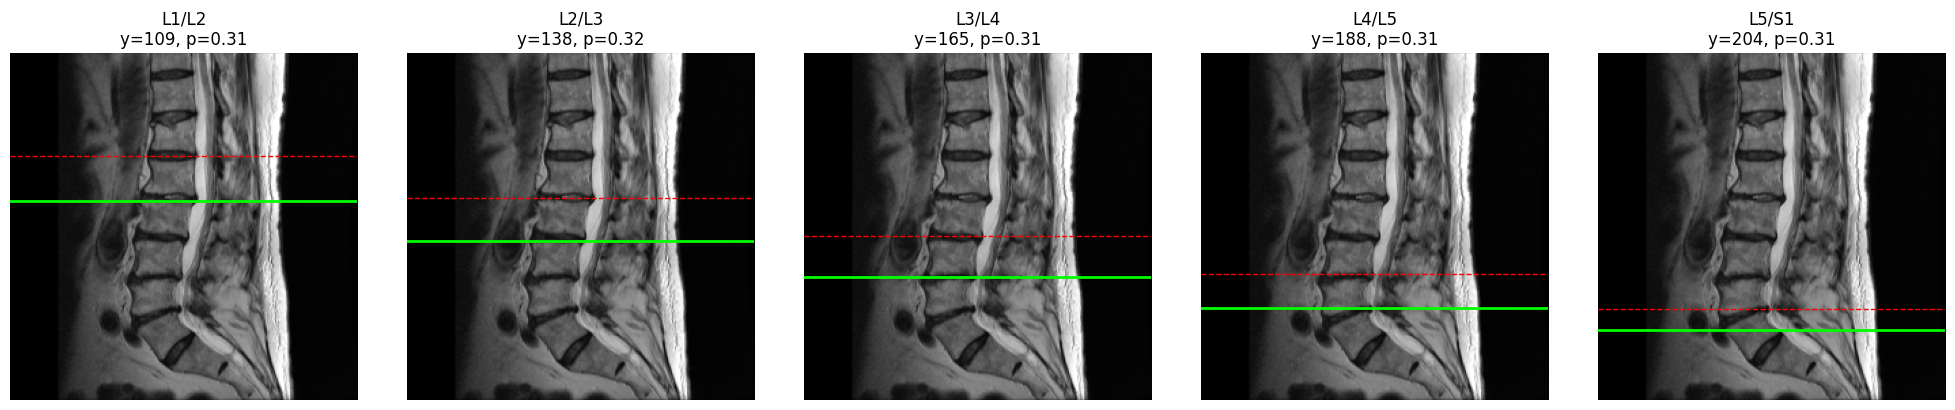

In [21]:
def plot_predictions_for_series(dataset: WholeSeriesCanalDataset, model, idx: int = 0, cfg: CFG = cfg):
    sample = dataset[idx]
    batch = collate_whole_series([sample])
    batch_dev = move_batch_to_device(batch, device)
    with torch.no_grad():
        probs = torch.sigmoid(model(batch_dev['image'])).cpu()
    pred_y = heatmap_argmax_y(probs).numpy()[0]
    img = sample['image'][0].numpy()

    # Show the middle sagittal slice only. Training uses a 3D ellipsoid target, but inference still returns only the level height.
    zi = img.shape[0] // 2
    n = len(cfg.levels)
    plt.figure(figsize=(4 * n, 4))
    for li, level in enumerate(cfg.levels):
        y = float(pred_y[li])
        plt.subplot(1, n, li + 1)
        plt.imshow(img[zi], cmap='gray')
        plt.axhline(y, color='lime', linewidth=2, label='pred height')
        if sample['level_mask'][li] > 0:
            gt_y = float(sample['coord_zyx'][li, 1])
            plt.axhline(gt_y, color='red', linewidth=1, linestyle='--', label='gt height')
        conf = float(heatmap_y_profile(probs)[0, li].max())
        plt.title(f'{level}\ny={y:.0f}, p={conf:.2f}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions_for_series(test_ds, model, idx=3, cfg=cfg)


In [23]:
# Evaluate predictions outside 10 px height error

HEIGHT_TOLERANCE_PX = 10

height_eval_df = pred_df.merge(
    test_df[['study_id', 'series_id', 'condition', 'level', 'y']],
    on=['study_id', 'series_id', 'condition', 'level'],
    how='inner'
)

height_eval_df['height_abs_error_px'] = (
    height_eval_df['pred_y'] - height_eval_df['y']
).abs()

height_eval_df['outside_10px'] = height_eval_df['height_abs_error_px'] > HEIGHT_TOLERANCE_PX

outside_10px_summary = (
    height_eval_df
    .groupby('level')
    .agg(
        n=('outside_10px', 'size'),
        outside_10px_count=('outside_10px', 'sum'),
        outside_10px_rate=('outside_10px', 'mean'),
        mean_height_abs_error_px=('height_abs_error_px', 'mean'),
        median_height_abs_error_px=('height_abs_error_px', 'median'),
    )
    .reindex(cfg.levels)
    .reset_index()
)

overall_outside_10px = pd.DataFrame([{
    'level': 'ALL',
    'n': len(height_eval_df),
    'outside_10px_count': int(height_eval_df['outside_10px'].sum()),
    'outside_10px_rate': float(height_eval_df['outside_10px'].mean()),
    'mean_height_abs_error_px': float(height_eval_df['height_abs_error_px'].mean()),
    'median_height_abs_error_px': float(height_eval_df['height_abs_error_px'].median()),
}])

display(pd.concat([outside_10px_summary, overall_outside_10px], ignore_index=True))

outside_10px_df = (
    height_eval_df[height_eval_df['outside_10px']]
    .sort_values('height_abs_error_px', ascending=False)
    .reset_index(drop=True)
)


,level,n,outside_10px_count,outside_10px_rate,mean_height_abs_error_px,median_height_abs_error_px
0,L1/L2,283,18,0.063604,5.557533,1.912207
1,L2/L3,288,12,0.041667,3.772410,1.577112
2,L3/L4,295,8,0.027119,3.392743,1.807487
3,L4/L5,295,7,0.023729,3.308584,1.719307
4,L5/S1,293,7,0.023891,3.242726,1.972028
5,ALL,1454,52,0.035763,3.841985,1.805916


Plotting idx=239, study_id=3496128487, series_id=2185202709, level=L2/L3, error=62.2px


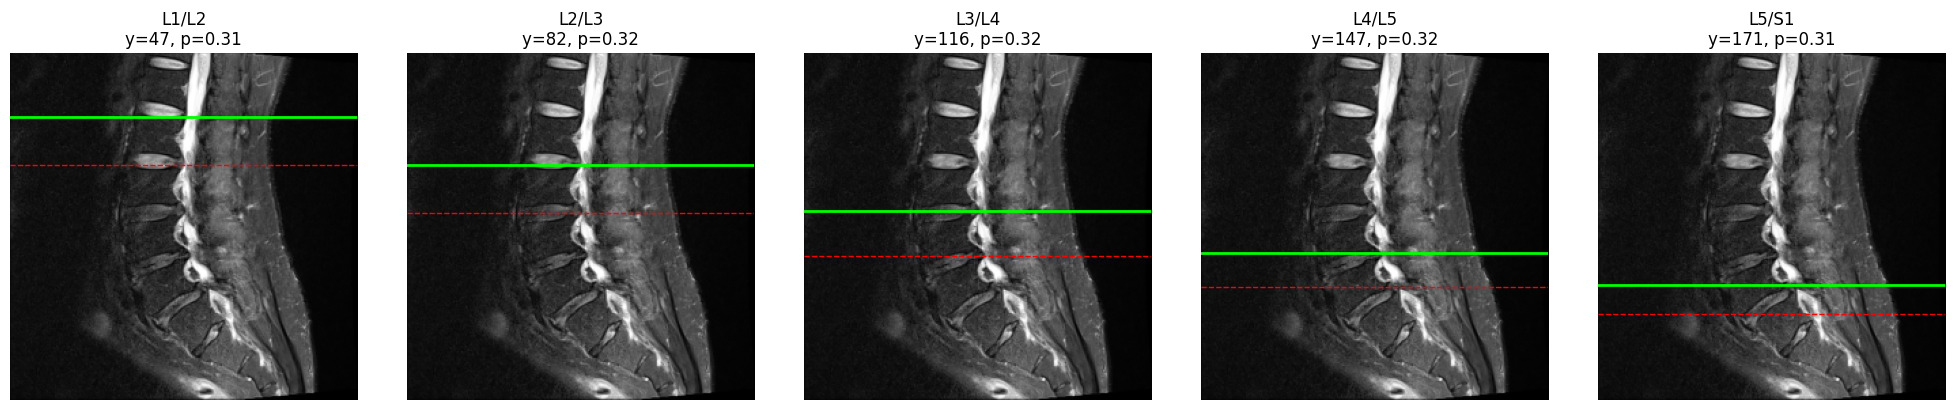

In [27]:
# Plot one outside-10px prediction by dataset index

bad_row = outside_10px_df.iloc[10]

bad_idx = test_ds.series_index.index[
    (test_ds.series_index['study_id'] == bad_row['study_id']) &
    (test_ds.series_index['series_id'] == bad_row['series_id'])
][0]

print(
    f"Plotting idx={bad_idx}, "
    f"study_id={bad_row['study_id']}, "
    f"series_id={bad_row['series_id']}, "
    f"level={bad_row['level']}, "
    f"error={bad_row['height_abs_error_px']:.1f}px"
)

plot_predictions_for_series(test_ds, model, idx=bad_idx, cfg=cfg)

Found 25 bad series with at least one level outside 10 px.
Bad series 1/25 | idx=133 | study_id=2056309275 | series_id=530257231


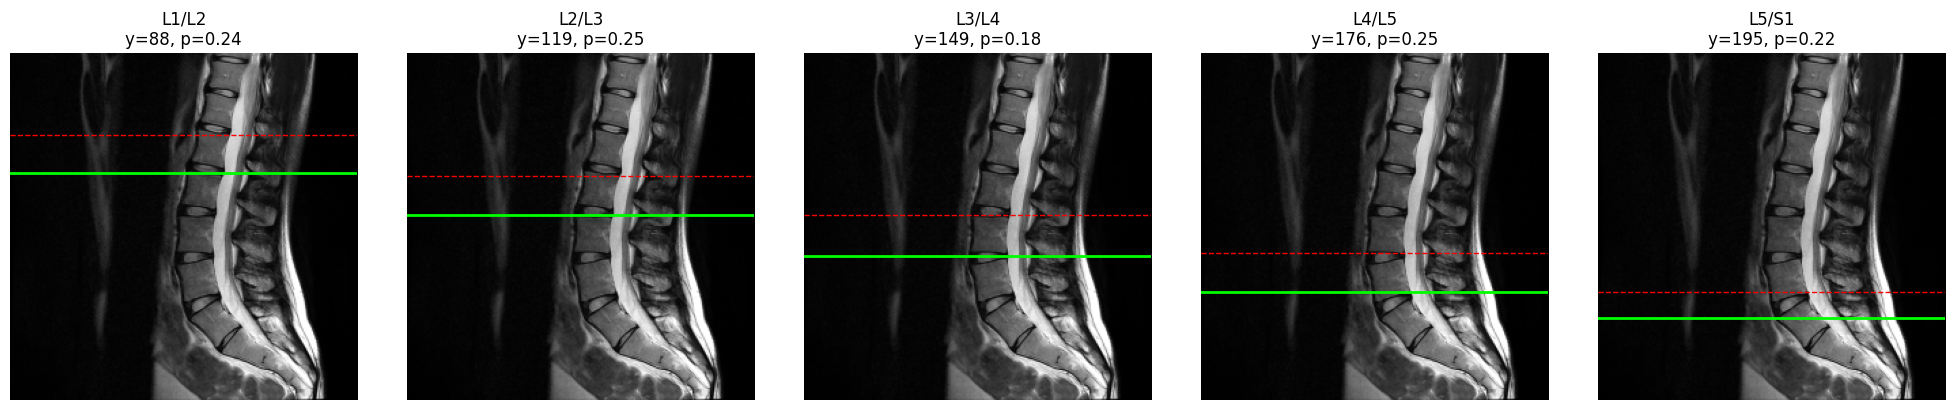

Bad series 2/25 | idx=129 | study_id=1973833645 | series_id=833708507


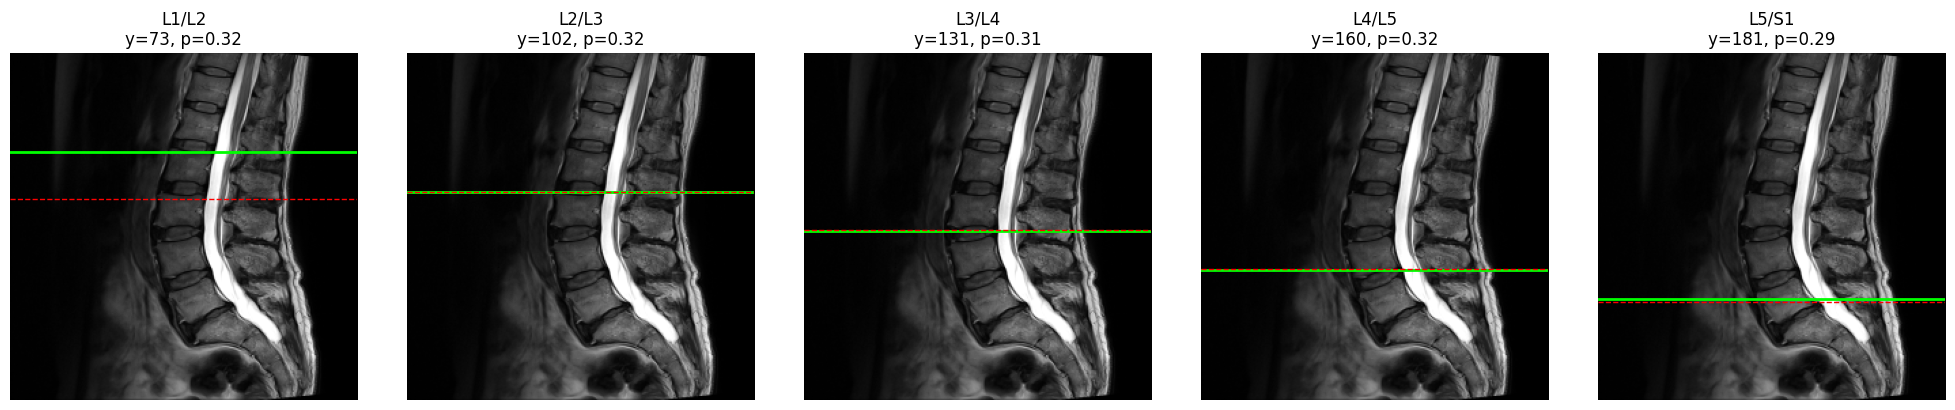

Bad series 3/25 | idx=255 | study_id=3713534743 | series_id=1113041349


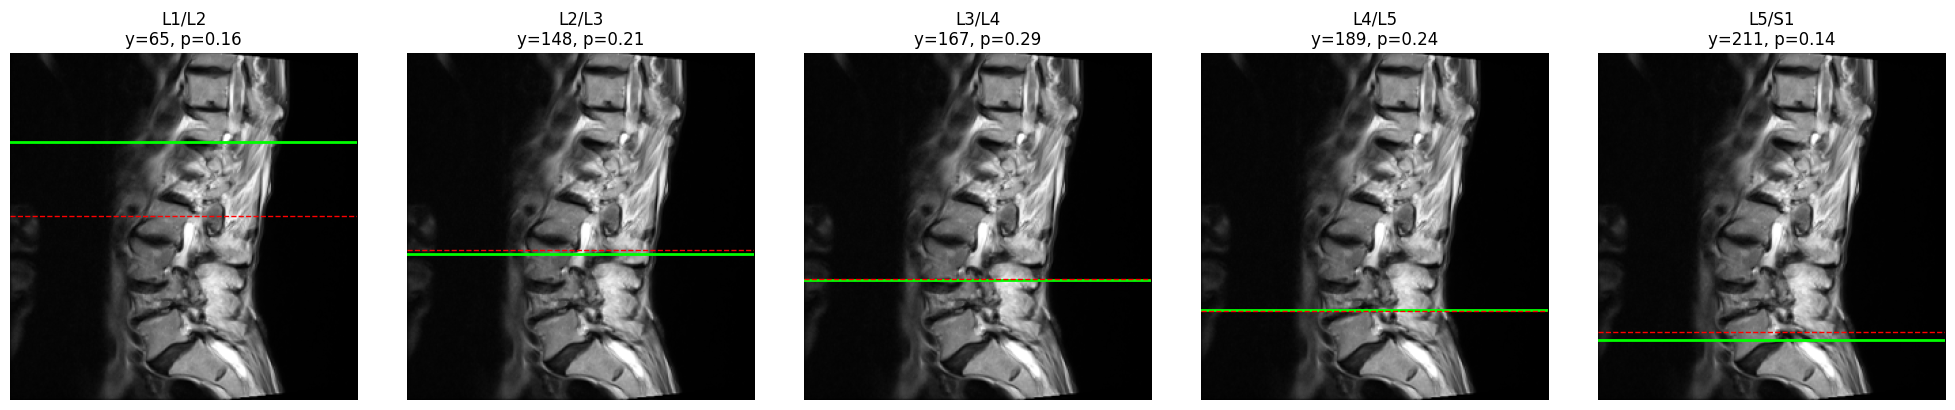

Bad series 4/25 | idx=226 | study_id=3303838960 | series_id=3702694446


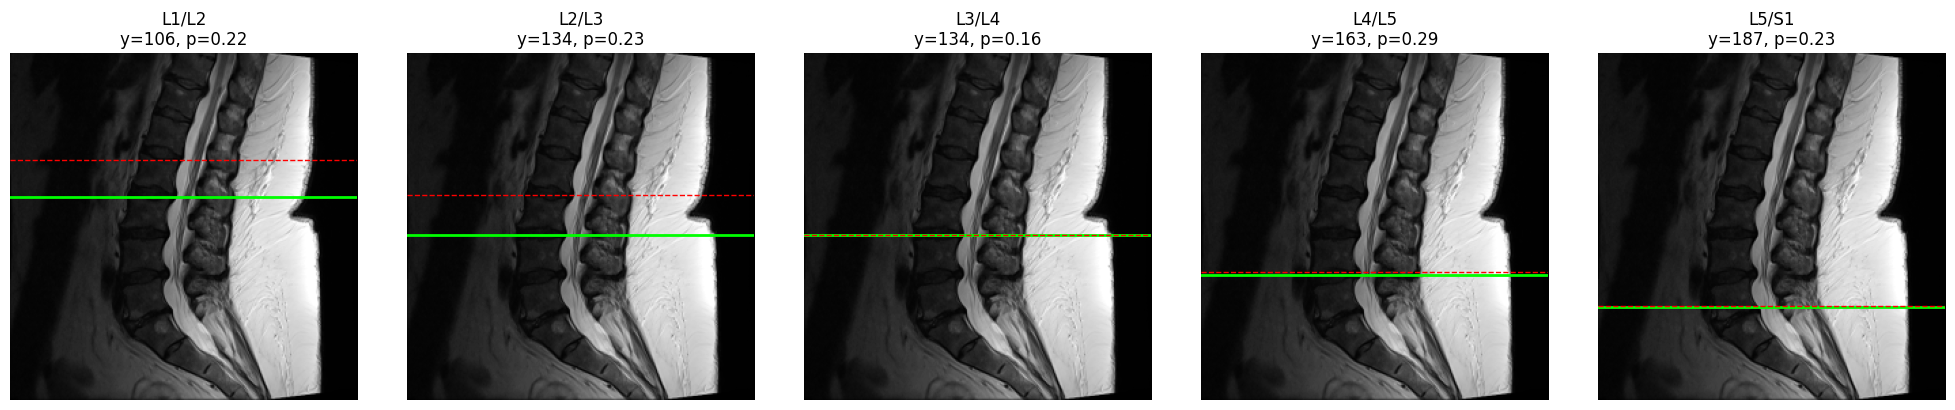

Bad series 5/25 | idx=3 | study_id=76438935 | series_id=3320474714


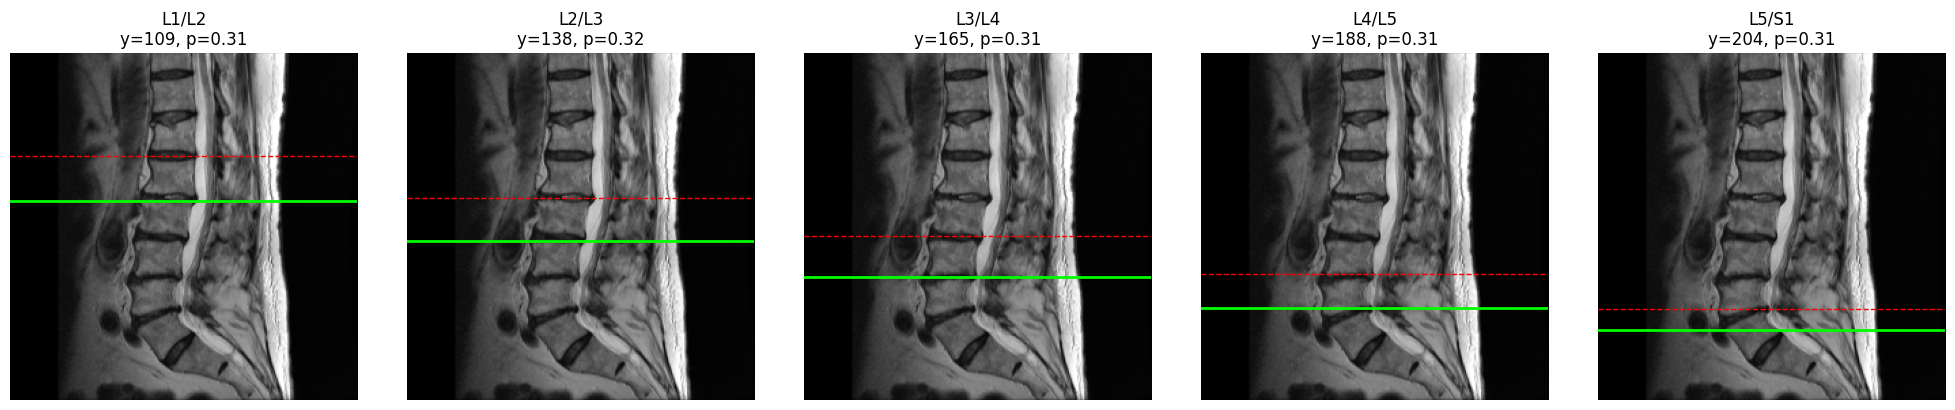

Bad series 6/25 | idx=239 | study_id=3496128487 | series_id=2185202709


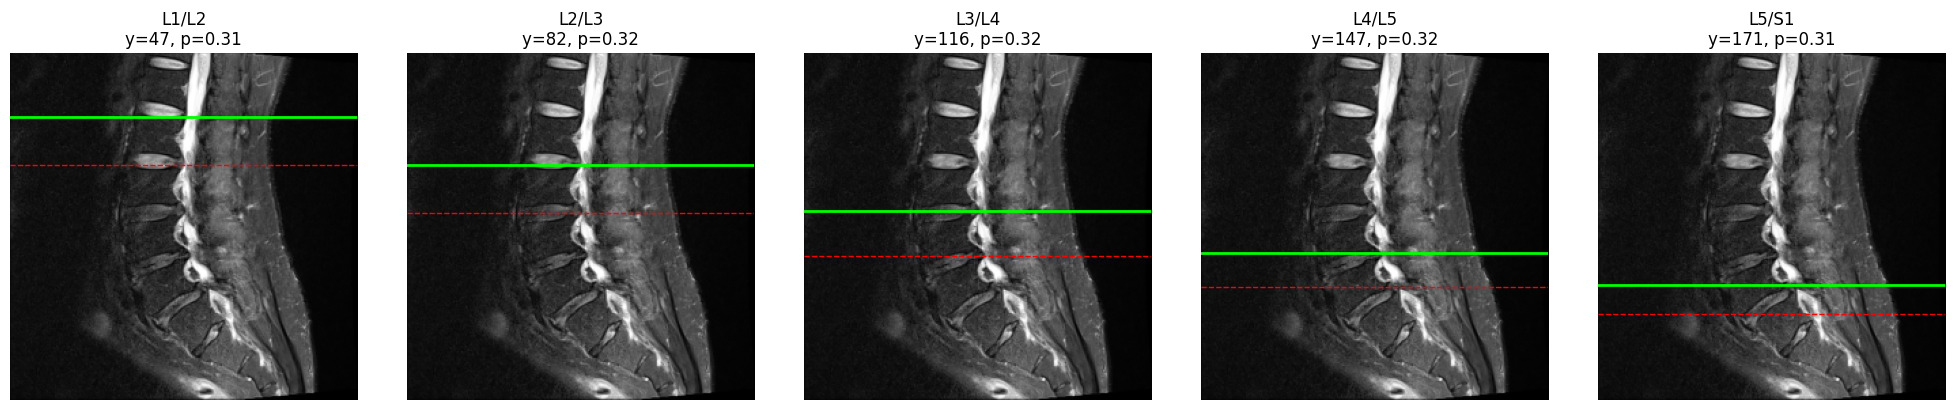

Bad series 7/25 | idx=78 | study_id=1117492266 | series_id=235772277


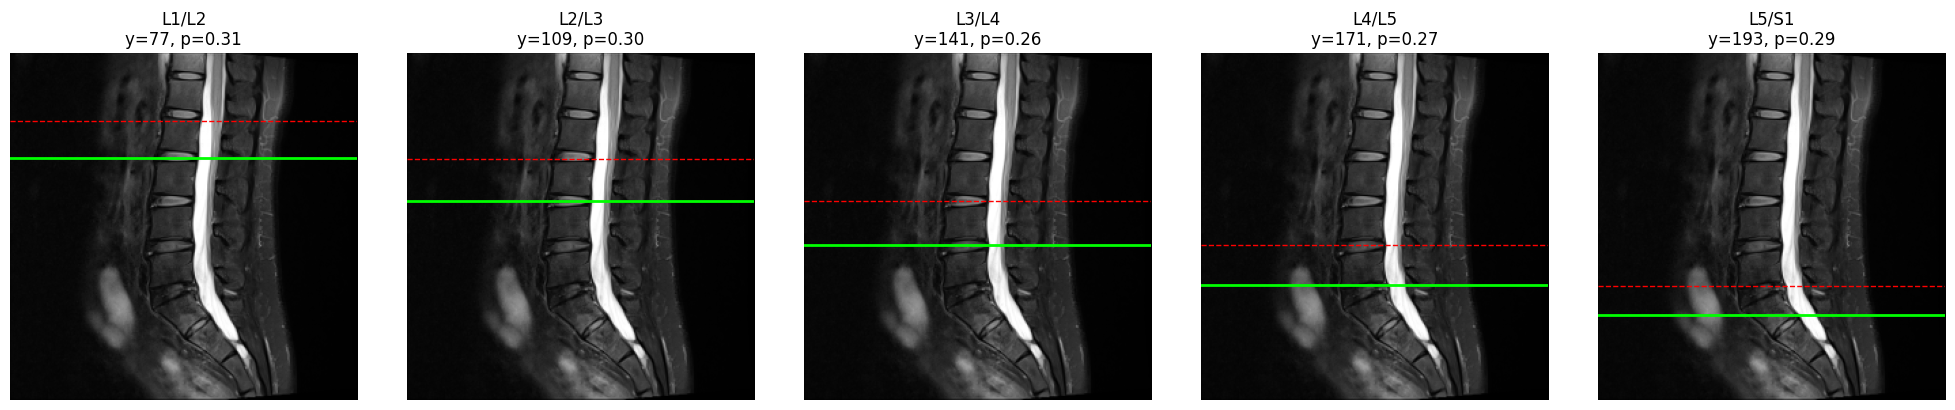

Bad series 8/25 | idx=53 | study_id=767443105 | series_id=3268622861


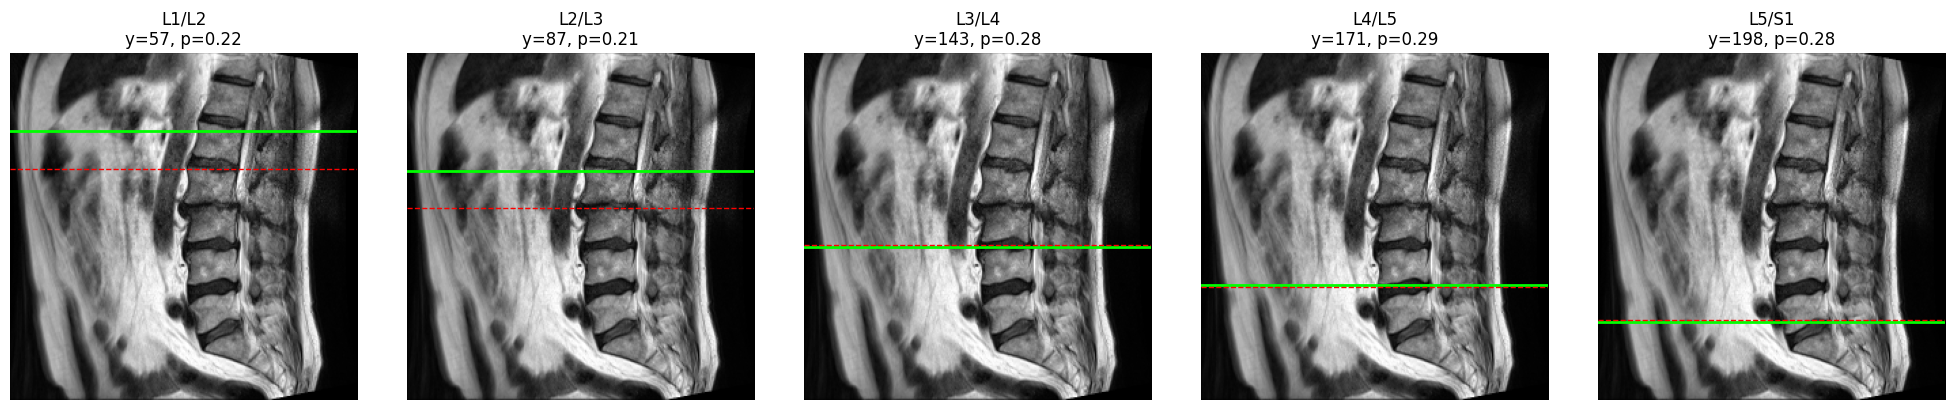

Bad series 9/25 | idx=26 | study_id=372642770 | series_id=1416772288


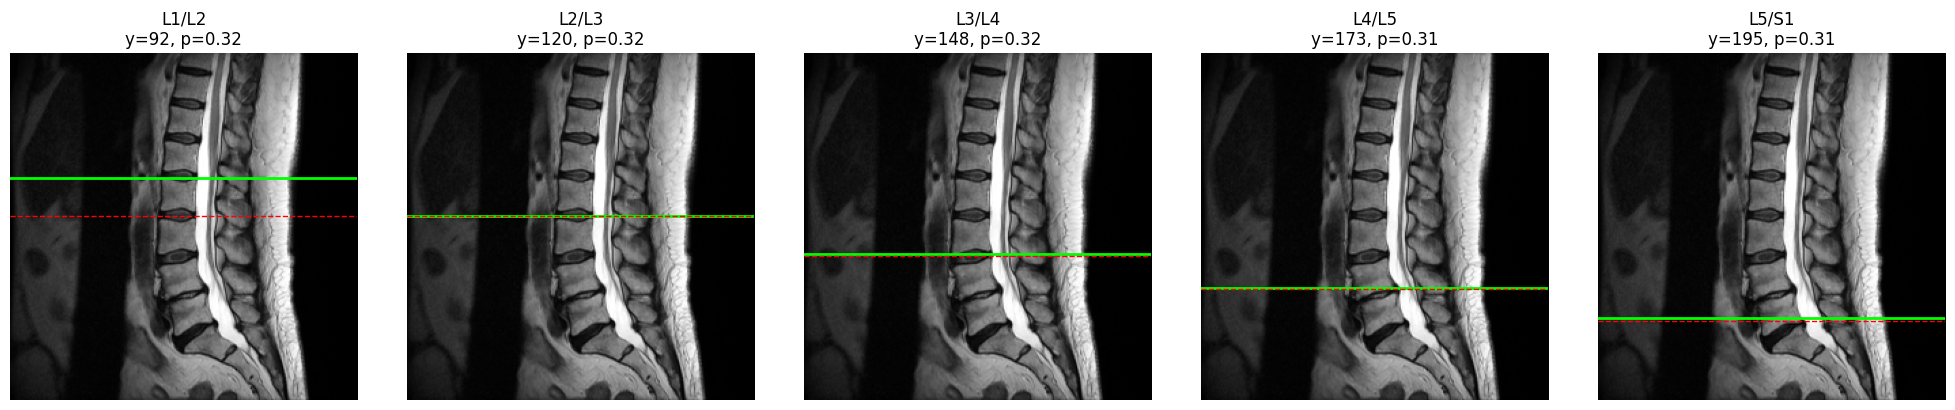

Bad series 10/25 | idx=66 | study_id=945809437 | series_id=485388386


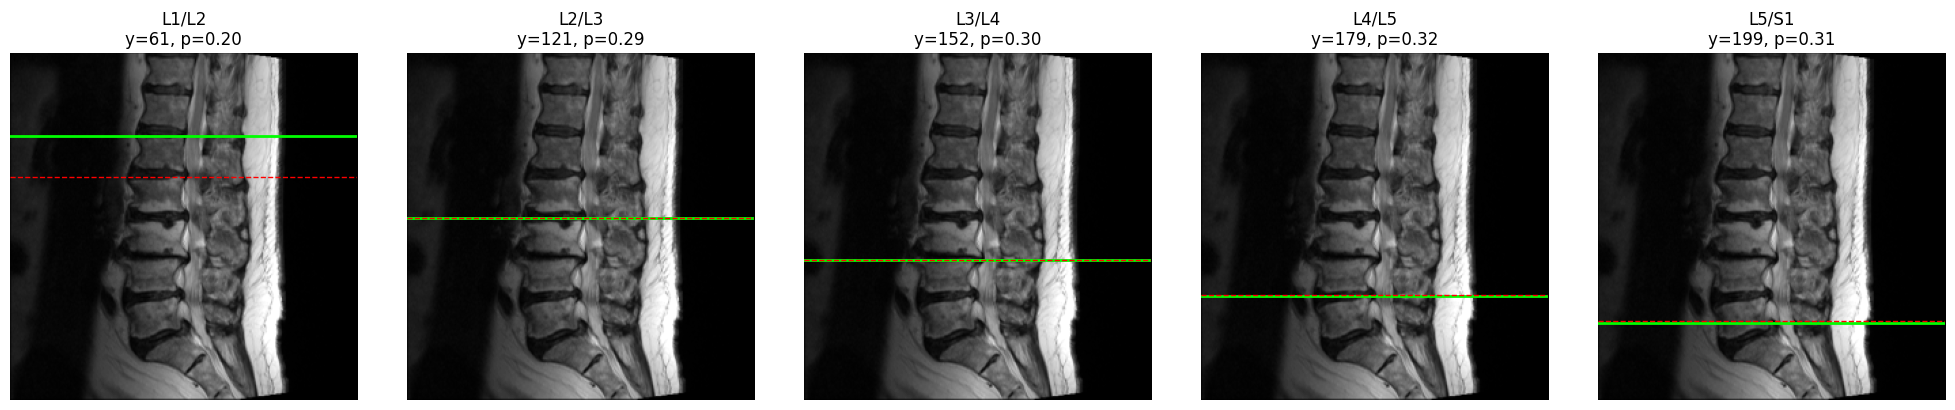

Bad series 11/25 | idx=52 | study_id=765688458 | series_id=2713404254


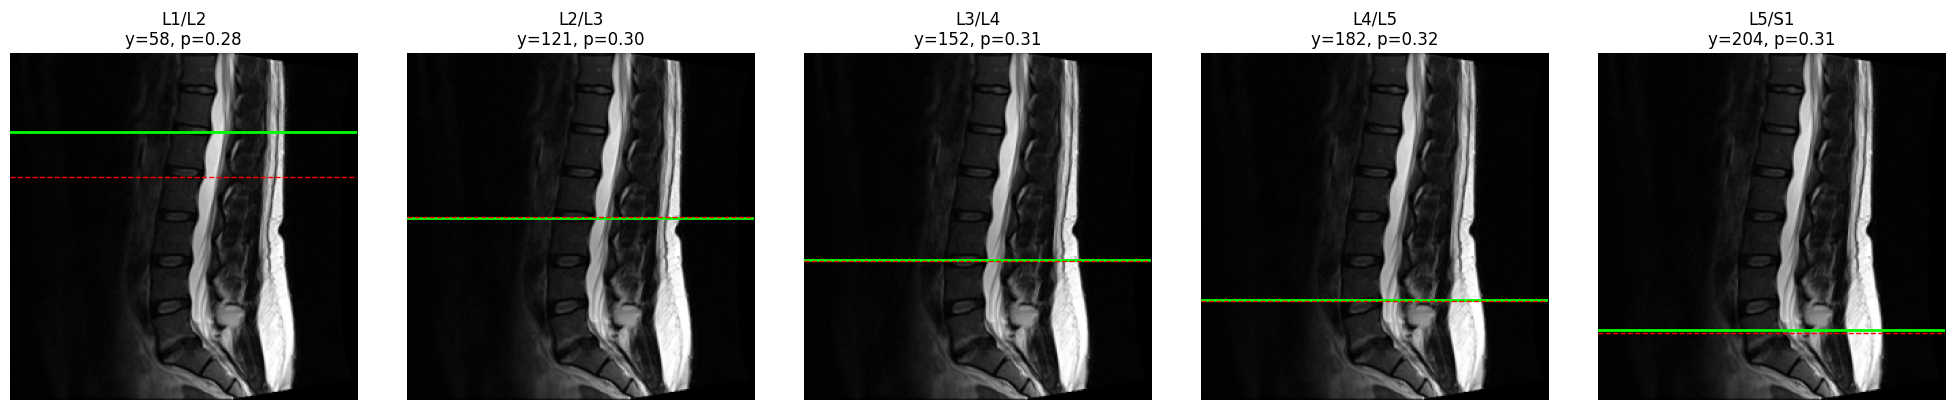

Bad series 12/25 | idx=264 | study_id=3847808992 | series_id=2709176468


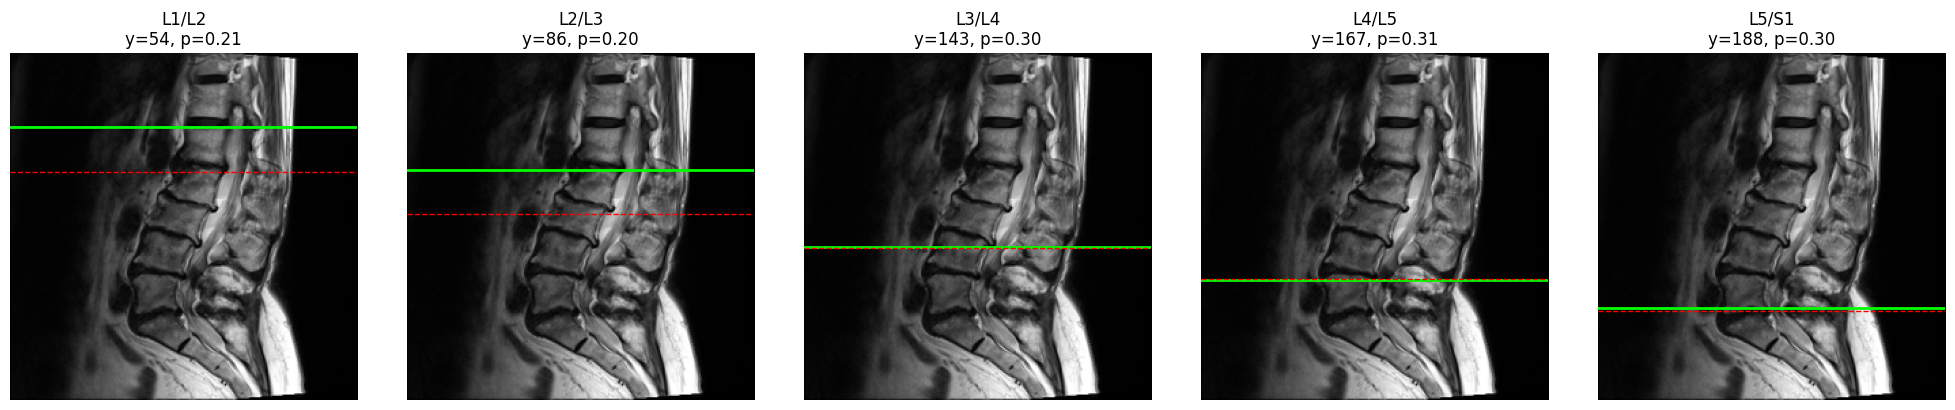

Bad series 13/25 | idx=68 | study_id=953639220 | series_id=270540558


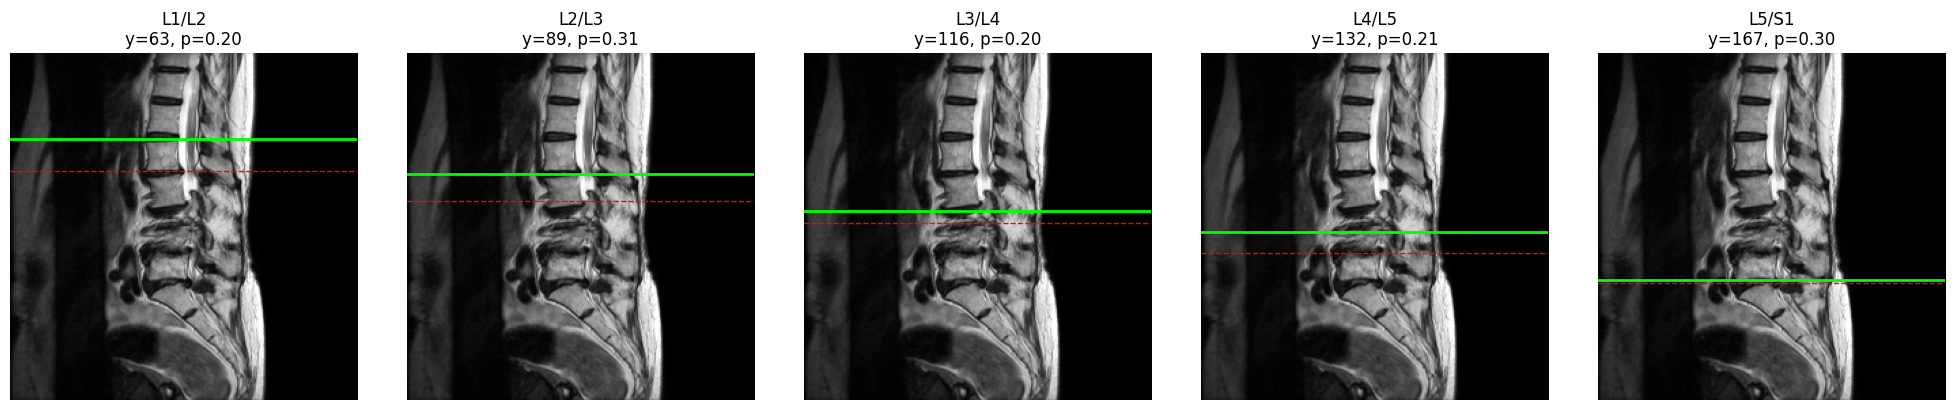

Bad series 14/25 | idx=159 | study_id=2466046363 | series_id=1478301987


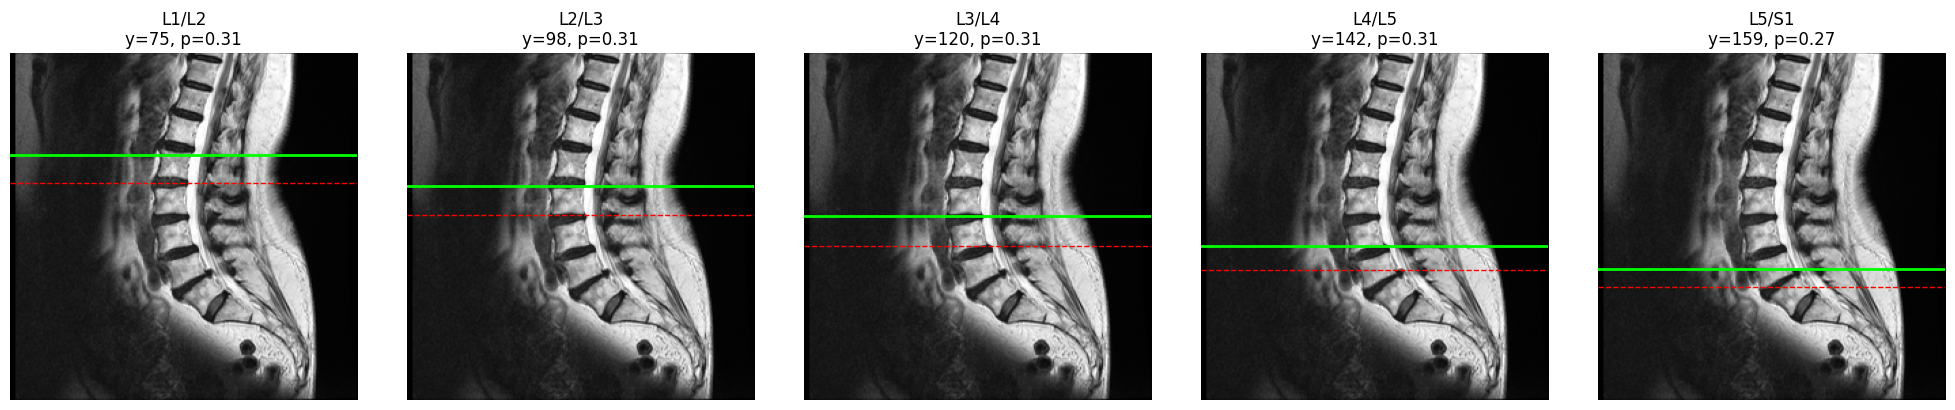

Bad series 15/25 | idx=212 | study_id=3109648055 | series_id=2987929703


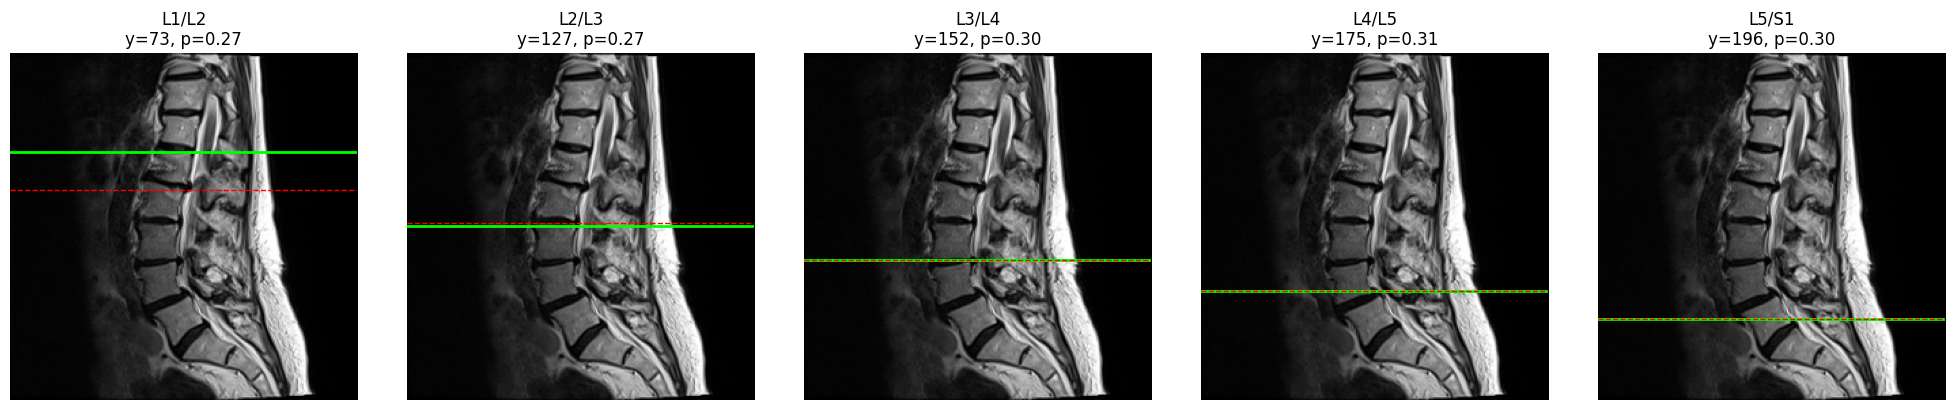

Bad series 16/25 | idx=175 | study_id=2676098721 | series_id=2602311872


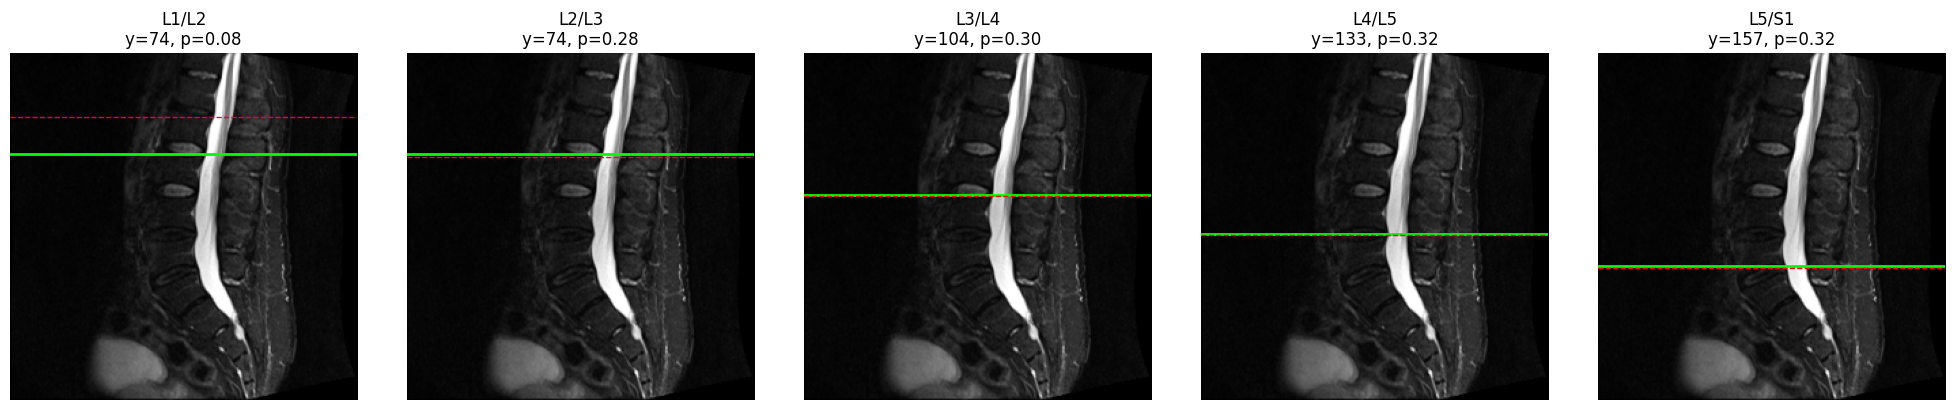

Bad series 17/25 | idx=236 | study_id=3461844320 | series_id=741750228


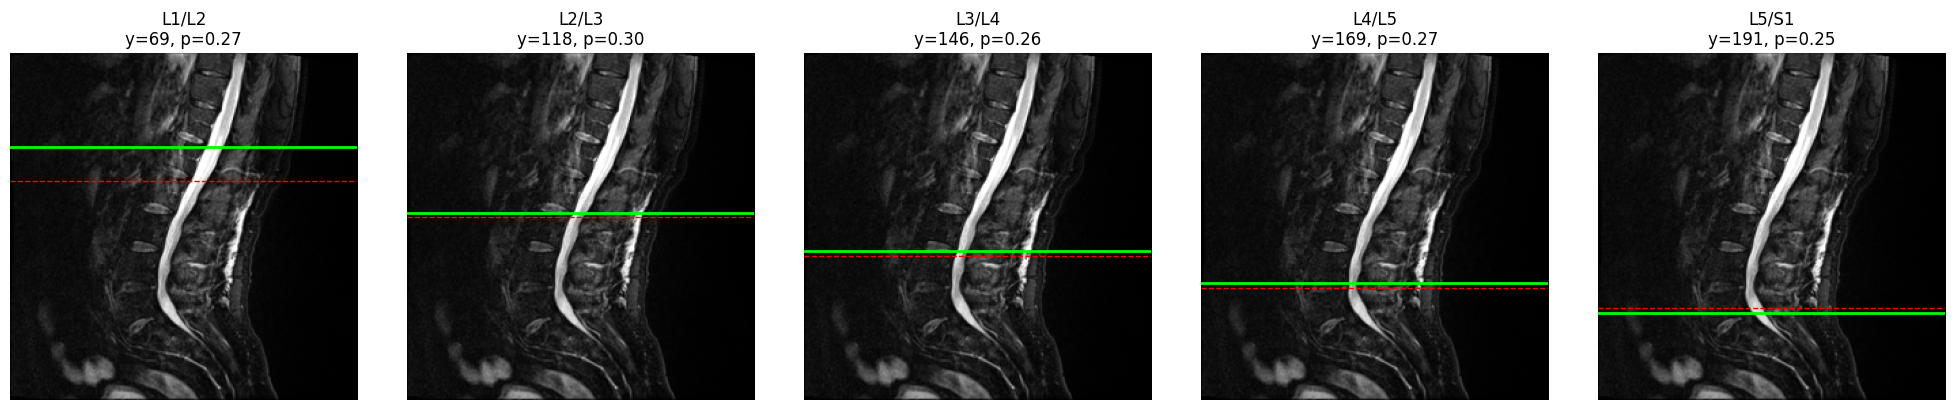

Bad series 18/25 | idx=203 | study_id=3018856000 | series_id=966658443


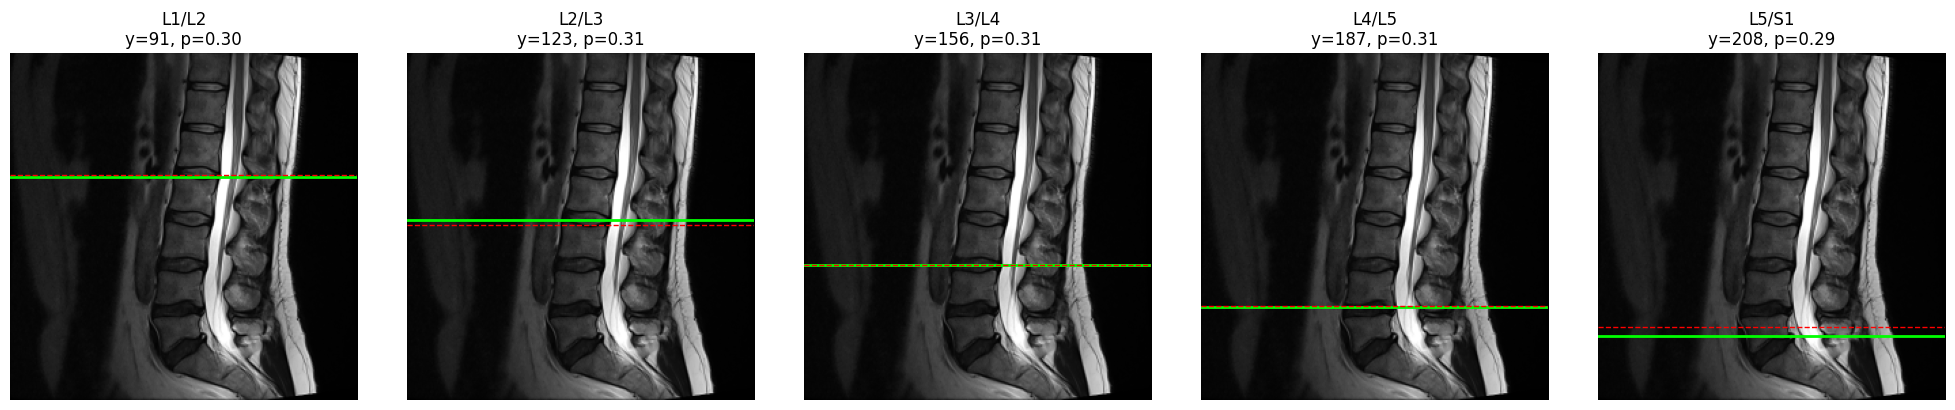

Bad series 19/25 | idx=155 | study_id=2411161648 | series_id=1716014076


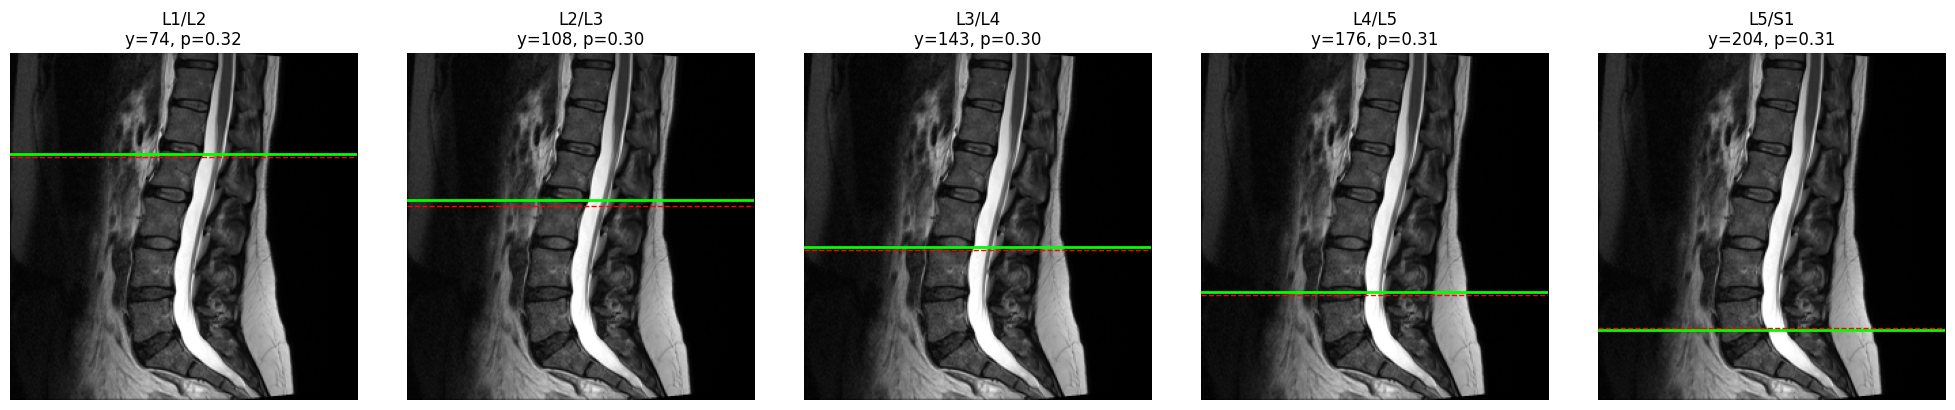

Bad series 20/25 | idx=89 | study_id=1271819130 | series_id=3637464851


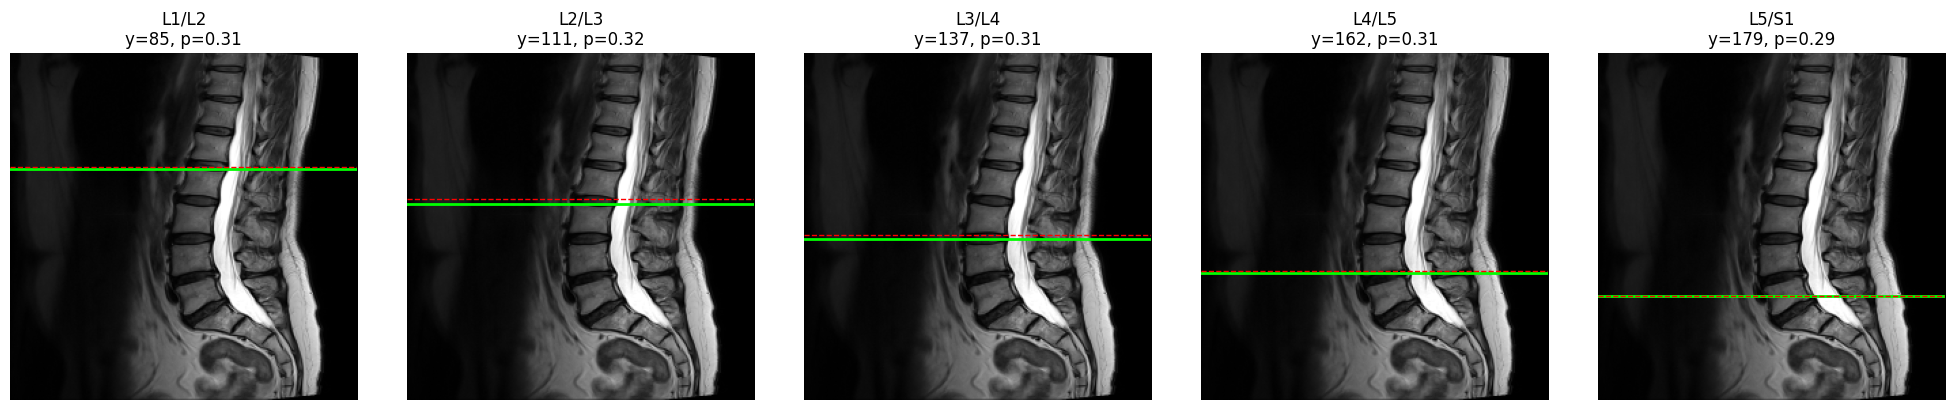

Bad series 21/25 | idx=103 | study_id=1536303104 | series_id=650362227


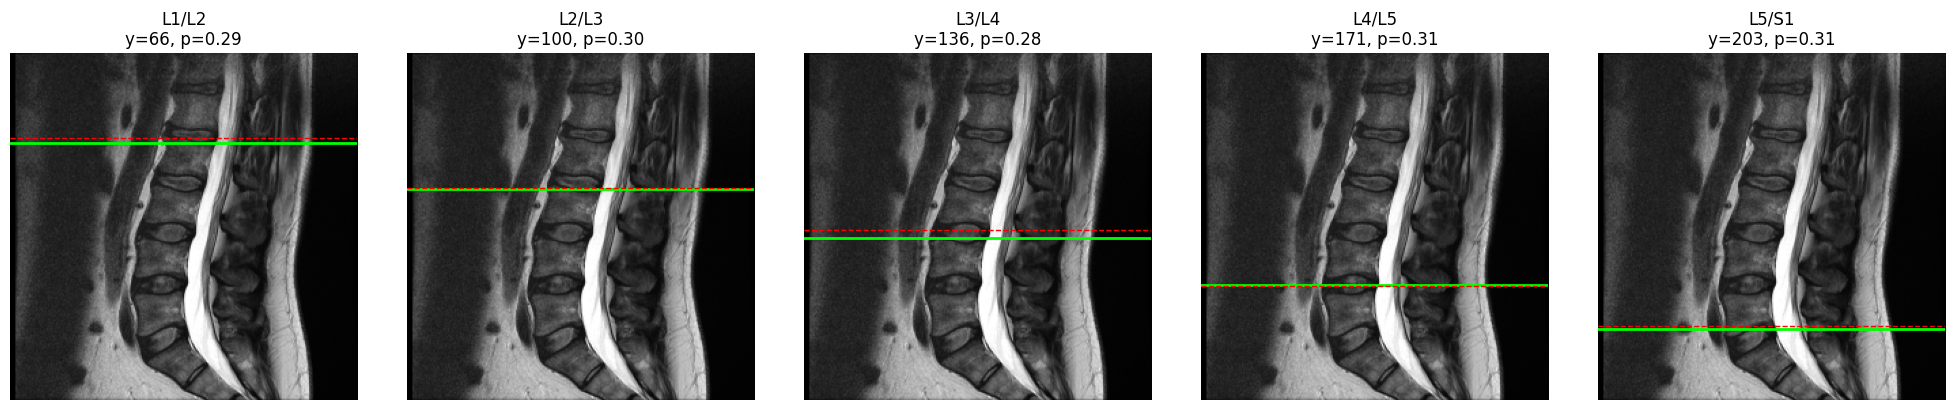

Bad series 22/25 | idx=225 | study_id=3303624762 | series_id=2565584358


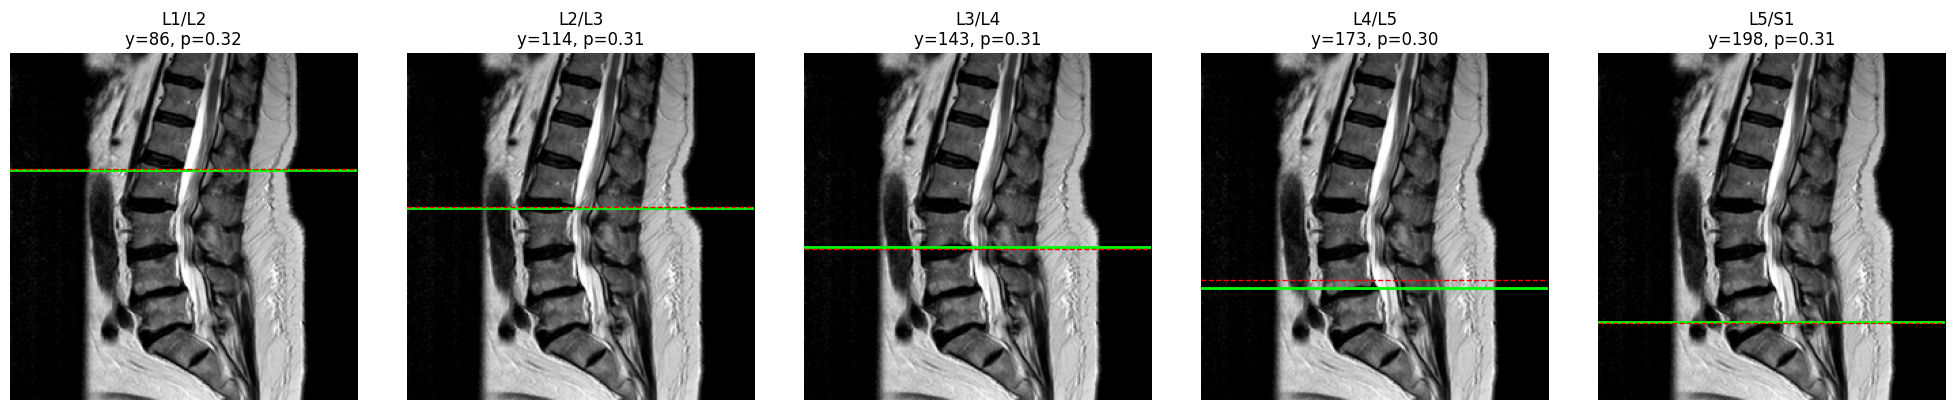

Bad series 23/25 | idx=157 | study_id=2445296690 | series_id=27564975


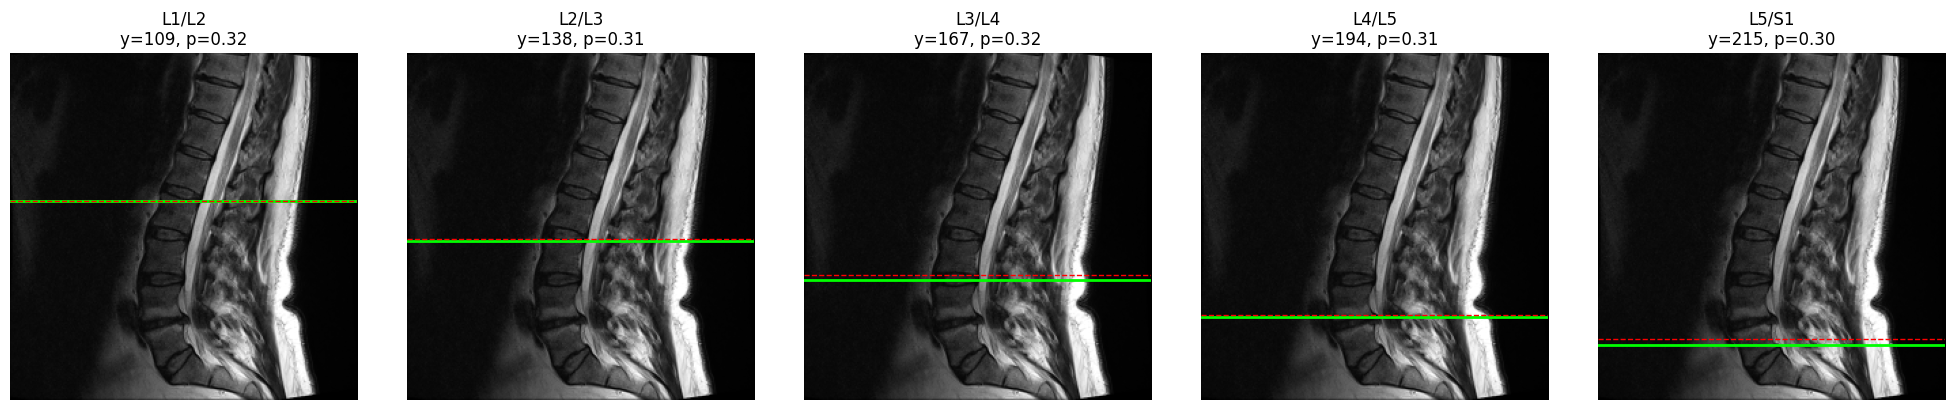

Bad series 24/25 | idx=59 | study_id=810180368 | series_id=2022560329


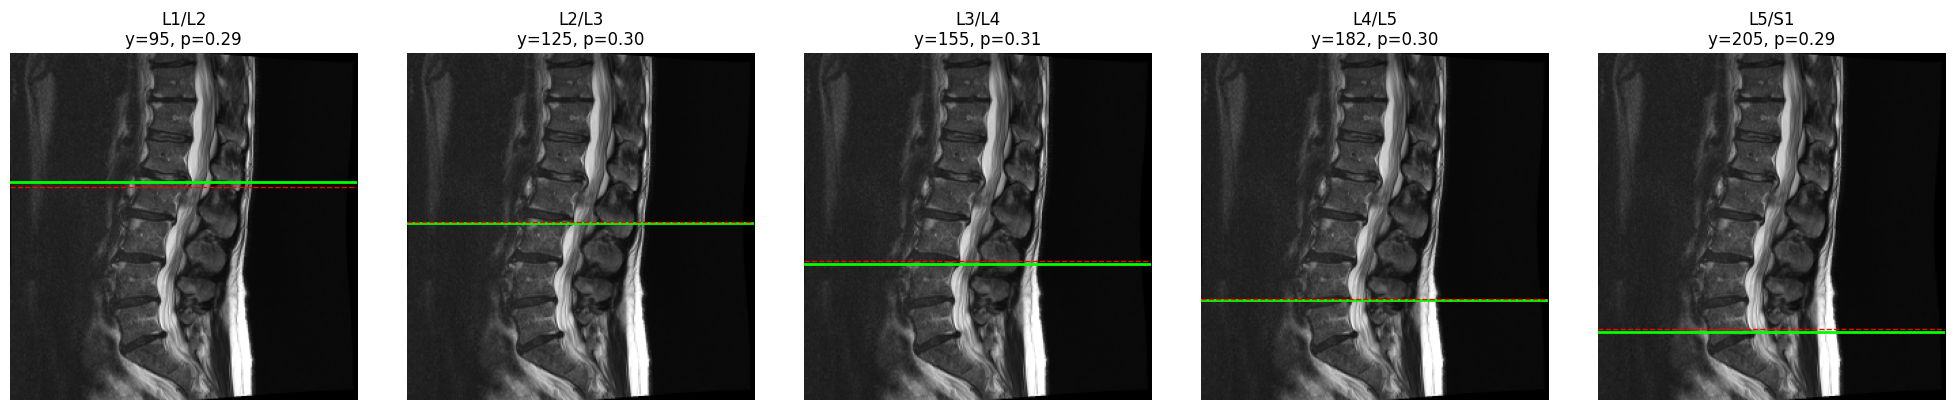

Bad series 25/25 | idx=218 | study_id=3201135301 | series_id=368879591


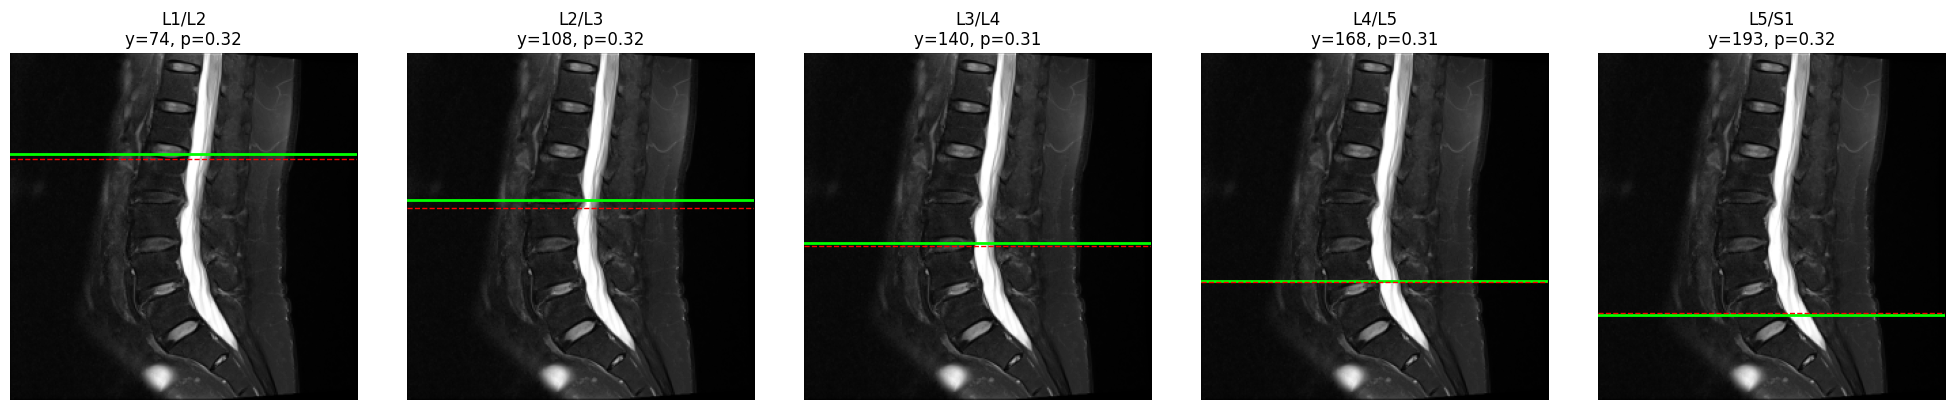

In [29]:
# Plot all series that have at least one level outside the 10 px tolerance

bad_series_df = (
    outside_10px_df[['study_id', 'series_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Found {len(bad_series_df)} bad series with at least one level outside 10 px.')

for i, row in bad_series_df.iterrows():
    bad_idx = test_ds.series_index.index[
        (test_ds.series_index['study_id'] == row['study_id']) &
        (test_ds.series_index['series_id'] == row['series_id'])
    ][0]

    bad_levels = outside_10px_df[
        (outside_10px_df['study_id'] == row['study_id']) &
        (outside_10px_df['series_id'] == row['series_id'])
    ][['level', 'height_abs_error_px']]

    print('=' * 80)
    print(
        f'Bad series {i + 1}/{len(bad_series_df)} | '
        f'idx={bad_idx} | '
        f'study_id={row["study_id"]} | '
        f'series_id={row["series_id"]}'
    )

    plot_predictions_for_series(test_ds, model, idx=bad_idx, cfg=cfg)

## Corrections

In [51]:
# U-Net-style correction config adapted to height-only 3D model

CORRECTION_TOP_K = 12
CORRECTION_NMS_RADIUS = 8
CORRECTION_MIN_CANDIDATE_SCORE = 0.0
CORRECTION_UNION_MODE = "max"   # "max" or "mean"

ORDER_MARGIN_PX = 0.0
RATIO_LOW_Q = 2.5
RATIO_HIGH_Q = 97.5

# Only apply correction to groups flagged by diagnosis, exactly like the U-Net notebook.
ONLY_DIAGNOSIS_BAD = True

In [52]:
def build_training_height_ratio_constraints(
    dataset,
    cfg,
    levels=None,
    low_q=2.5,
    high_q=97.5,
    min_valid_dist=1e-6,
):
    """
    Height-only equivalent of U-Net euclidean ratio constraints.

    For every training series with all 5 levels, compute adjacent y spacings:

        d01 = y_L2L3 - y_L1L2
        d12 = y_L3L4 - y_L2L3
        d23 = y_L4L5 - y_L3L4
        d34 = y_L5S1 - y_L4L5

    Then compute ratios relative to the median adjacent spacing of that same series.
    This makes the constraint scale-invariant across different patient sizes.
    """
    if levels is None:
        levels = list(cfg.levels)

    rows = []

    for idx in tqdm(range(len(dataset)), desc="building height ratio constraints"):
        sample = dataset[idx]
        coord = sample["coord_zyx"].numpy()      # [5, 3]
        level_mask = sample["level_mask"].numpy() > 0

        if not level_mask.all():
            continue

        y = coord[:, 1].astype(np.float32)

        if not np.isfinite(y).all():
            continue

        gaps = np.diff(y)

        if np.any(gaps <= min_valid_dist):
            continue

        ref_gap = float(np.median(gaps))

        if ref_gap <= min_valid_dist:
            continue

        for pair_idx in range(len(levels) - 1):
            rows.append({
                "pair_idx": pair_idx,
                "from_level": levels[pair_idx],
                "to_level": levels[pair_idx + 1],
                "gap_px": float(gaps[pair_idx]),
                "ref_gap_px": ref_gap,
                "ratio": float(gaps[pair_idx] / ref_gap),
            })

    ratio_df = pd.DataFrame(rows)

    constraints = (
        ratio_df
        .groupby(["pair_idx", "from_level", "to_level"])
        .agg(
            ratio_median=("ratio", "median"),
            ratio_low=("ratio", lambda s: np.percentile(s, low_q)),
            ratio_high=("ratio", lambda s: np.percentile(s, high_q)),
            gap_median=("gap_px", "median"),
            gap_low=("gap_px", lambda s: np.percentile(s, low_q)),
            gap_high=("gap_px", lambda s: np.percentile(s, high_q)),
            n=("ratio", "size"),
        )
        .reset_index()
    )

    print("Height ratio constraints:")
    display(constraints)

    return ratio_df, constraints

In [53]:
train_height_ratio_df, height_ratio_constraints = build_training_height_ratio_constraints(
    dataset=train_ds,
    cfg=cfg,
    levels=list(cfg.levels),
    low_q=RATIO_LOW_Q,
    high_q=RATIO_HIGH_Q,
)

building height ratio constraints:   0%|          | 0/1381 [00:00<?, ?it/s]

Height ratio constraints:


,pair_idx,from_level,to_level,ratio_median,ratio_low,ratio_high,gap_median,gap_low,gap_high,n
0,0,L1/L2,L2/L3,1.042017,0.950000,1.221239,29.728584,22.755402,36.771278,1321
1,1,L2/L3,L3/L4,1.037681,0.937500,1.216081,29.516136,22.598289,36.932655,1321
2,2,L3/L4,L4/L5,0.990291,0.855615,1.106882,28.013611,20.645920,35.431747,1321
3,3,L4/L5,L5/S1,0.826087,0.577999,1.007408,23.146255,15.067520,31.156403,1321


In [54]:
def diagnose_all5_height_relative_spacing(
    pred_df,
    ratio_constraints,
    cfg,
    group_cols=None,
    levels=None,
    level_col="level",
    level_idx_col="level_idx",
    y_col="pred_y_resized",
    order_margin_px=0.0,
    min_ref_dist_px=1e-6,
):
    """
    Diagnose whether each 5-level prediction group is anatomically plausible.

    Uses only model predictions, no ground truth.
    """
    if levels is None:
        levels = list(cfg.levels)

    if group_cols is None:
        group_cols = ["study_id", "series_id", "condition"]

    pred_df = pred_df.copy()

    pair_rows = []
    group_rows = []

    constraints_by_pair = {
        int(r["pair_idx"]): r
        for _, r in ratio_constraints.iterrows()
    }

    for group_key, g in pred_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(group_cols, group_key))

        gg = (
            g[g[level_col].isin(levels)]
            .sort_values(level_idx_col)
            .copy()
        )

        if len(gg) != len(levels):
            group_rows.append({
                **group_info,
                "n_levels": len(gg),
                "order_ok": False,
                "height_spacing_ok": False,
                "diagnosis_bad": True,
                "n_order_bad_pairs": np.nan,
                "n_ratio_bad_pairs": np.nan,
                "predicted_order_by_y": None,
            })
            continue

        y = gg[y_col].astype(float).values
        gaps = np.diff(y)

        ref_gap = float(np.median(gaps[gaps > min_ref_dist_px])) if np.any(gaps > min_ref_dist_px) else np.nan

        order_bad = gaps <= order_margin_px
        ratio_bad_list = []

        predicted_order_by_y = " -> ".join(
            gg.iloc[np.argsort(y)][level_col].astype(str).tolist()
        )

        for pair_idx in range(len(levels) - 1):
            c = constraints_by_pair[pair_idx]

            gap = float(gaps[pair_idx])

            if not np.isfinite(ref_gap) or ref_gap <= min_ref_dist_px:
                ratio = np.nan
                ratio_bad = True
            else:
                ratio = gap / ref_gap
                ratio_bad = (
                    ratio < float(c["ratio_low"])
                    or ratio > float(c["ratio_high"])
                )

            ratio_bad_list.append(ratio_bad)

            pair_rows.append({
                **group_info,
                "pair_idx": pair_idx,
                "from_level": levels[pair_idx],
                "to_level": levels[pair_idx + 1],
                "from_y": float(y[pair_idx]),
                "to_y": float(y[pair_idx + 1]),
                "gap_px": gap,
                "ref_gap_px": ref_gap,
                "ratio": ratio,
                "ratio_low": float(c["ratio_low"]),
                "ratio_high": float(c["ratio_high"]),
                "order_ok": bool(not order_bad[pair_idx]),
                "ratio_ok": bool(not ratio_bad),
                "pair_bad": bool(order_bad[pair_idx] or ratio_bad),
            })

        order_ok = not bool(np.any(order_bad))
        height_spacing_ok = not bool(np.any(ratio_bad_list))
        diagnosis_bad = not (order_ok and height_spacing_ok)

        group_rows.append({
            **group_info,
            "n_levels": len(gg),
            "order_ok": order_ok,
            "height_spacing_ok": height_spacing_ok,
            "diagnosis_bad": diagnosis_bad,
            "n_order_bad_pairs": int(np.sum(order_bad)),
            "n_ratio_bad_pairs": int(np.sum(ratio_bad_list)),
            "predicted_order_by_y": predicted_order_by_y,
            "raw_y_sequence": y.tolist(),
            "raw_gap_sequence": gaps.tolist(),
        })

    group_diag_df = pd.DataFrame(group_rows)
    pair_diag_df = pd.DataFrame(pair_rows)

    return group_diag_df, pair_diag_df

In [56]:
group_diag_height_df, pair_diag_height_df = diagnose_all5_height_relative_spacing(
    pred_df=pred_df,
    ratio_constraints=height_ratio_constraints,
    cfg=cfg,
    group_cols=["study_id", "series_id", "condition"],
    levels=list(cfg.levels),
    y_col="pred_y_resized",
    order_margin_px=ORDER_MARGIN_PX,
)

print("Total groups:", len(group_diag_height_df))
print("Diagnosis bad:", int(group_diag_height_df["diagnosis_bad"].sum()))
print("Order bad:", int((~group_diag_height_df["order_ok"]).sum()))
print("Height spacing bad:", int((~group_diag_height_df["height_spacing_ok"]).sum()))

Total groups: 296
Diagnosis bad: 29
Order bad: 2
Height spacing bad: 29


In [57]:
def nms_topk_1d(profile, top_k=12, radius=8, min_score=0.0):
    """
    1D non-maximum suppression for y-profile candidates.
    """
    profile = np.asarray(profile, dtype=np.float32).copy()
    selected = []

    for _ in range(top_k):
        y = int(np.argmax(profile))
        score = float(profile[y])

        if score < min_score:
            break

        selected.append((y, score))

        lo = max(0, y - radius)
        hi = min(len(profile), y + radius + 1)
        profile[lo:hi] = -np.inf

    return selected


def make_union_y_profile(y_profiles, mode="max"):
    """
    y_profiles: [5, H]
    """
    if mode == "max":
        return np.max(y_profiles, axis=0)
    elif mode == "mean":
        return np.mean(y_profiles, axis=0)
    else:
        raise ValueError(f"Unknown union mode: {mode}")


@torch.no_grad()
def get_y_profiles_for_series(dataset, model, idx, cfg):
    sample = dataset[idx]
    batch = collate_whole_series([sample])
    batch_dev = move_batch_to_device(batch, device)

    model.eval()
    logits = model(batch_dev["image"])
    probs = torch.sigmoid(logits).detach().cpu()

    y_profiles = heatmap_y_profile(probs)[0].numpy()  # [5, H]

    return y_profiles, sample


def get_dataset_idx_by_series(dataset, study_id, series_id):
    mask = (
        (dataset.series_index["study_id"].astype(int) == int(study_id))
        & (dataset.series_index["series_id"].astype(int) == int(series_id))
    )
    idxs = np.where(mask.values)[0]
    if len(idxs) == 0:
        raise ValueError(f"Could not find study_id={study_id}, series_id={series_id}")
    return int(idxs[0])

In [58]:
def score_height_sequence_unet_style(
    ys,
    y_profiles,
    ratio_constraints,
    cfg,
    confidence_weight=1.0,
    ratio_weight=1.0,
    raw_anchor_weight=0.02,
    raw_y=None,
    min_ref_dist_px=1e-6,
):
    """
    Score a candidate 5-level y sequence.

    Lower score is better.
    """
    ys = np.asarray(ys, dtype=np.float32)

    if np.any(np.diff(ys) <= 0):
        return np.inf

    gaps = np.diff(ys)

    valid_gaps = gaps[gaps > min_ref_dist_px]
    if len(valid_gaps) == 0:
        return np.inf

    ref_gap = float(np.median(valid_gaps))
    if ref_gap <= min_ref_dist_px:
        return np.inf

    score = 0.0

    # 1) Level-specific heatmap confidence at assigned candidate y.
    for li, y in enumerate(ys):
        yy = int(round(y))
        yy = int(np.clip(yy, 0, y_profiles.shape[1] - 1))
        conf = float(y_profiles[li, yy])
        score += confidence_weight * (-np.log(conf + 1e-6))

    # 2) Relative spacing ratio penalty, same architecture as U-Net diagnosis.
    constraints_by_pair = {
        int(r["pair_idx"]): r
        for _, r in ratio_constraints.iterrows()
    }

    for pair_idx in range(len(cfg.levels) - 1):
        c = constraints_by_pair[pair_idx]
        ratio = float(gaps[pair_idx] / ref_gap)

        low = float(c["ratio_low"])
        high = float(c["ratio_high"])
        med = float(c["ratio_median"])

        # Hard reject if outside learned U-Net-style ratio limits.
        if ratio < low or ratio > high:
            return np.inf

        # Soft preference for median ratio.
        denom = max((high - low) / 4.0, 1e-6)
        score += ratio_weight * ((ratio - med) / denom) ** 2

    # 3) Small anchor to raw prediction so correction does not move unnecessarily.
    if raw_y is not None:
        raw_y = np.asarray(raw_y, dtype=np.float32)
        score += raw_anchor_weight * np.sum(((ys - raw_y) / 10.0) ** 2)

    return float(score)


def correct_using_union_y_profiles_topk(
    pred_df,
    group_diag_df,
    ratio_constraints,
    dataset,
    model,
    cfg,
    top_k=12,
    nms_radius=8,
    min_candidate_score=0.0,
    union_mode="max",
    only_diagnosis_bad=True,
):
    """
    Height-only 3D adaptation of the U-Net correction architecture:

    1. diagnose all-5 prediction geometry
    2. for flagged groups, build union raw y-profile
    3. extract top-K union candidates
    4. choose the best ordered 5-level assignment using ratio constraints
    """
    corrected_df = pred_df.copy()
    report_rows = []

    group_cols = ["study_id", "series_id", "condition"]

    diag_lookup = {
        tuple(row[c] for c in group_cols): row
        for _, row in group_diag_df.iterrows()
    }

    for group_key, g in tqdm(pred_df.groupby(group_cols, dropna=False), desc="U-Net-style union correction"):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(group_cols, group_key))
        diag_row = diag_lookup.get(group_key, None)

        diagnosis_bad = bool(diag_row["diagnosis_bad"]) if diag_row is not None else True

        if only_diagnosis_bad and not diagnosis_bad:
            report_rows.append({
                **group_info,
                "status": "kept_diagnosis_ok",
                "diagnosis_bad": diagnosis_bad,
                "n_candidates": np.nan,
                "best_score": np.nan,
            })
            continue

        study_id = int(group_info["study_id"])
        series_id = int(group_info["series_id"])
        idx = get_dataset_idx_by_series(dataset, study_id, series_id)

        y_profiles, sample = get_y_profiles_for_series(dataset, model, idx, cfg)

        raw_rows = (
            g[g["level"].isin(cfg.levels)]
            .sort_values("level_idx")
            .copy()
        )

        if len(raw_rows) != len(cfg.levels):
            report_rows.append({
                **group_info,
                "status": "skipped_missing_levels",
                "diagnosis_bad": diagnosis_bad,
                "n_candidates": np.nan,
                "best_score": np.nan,
            })
            continue

        raw_y = raw_rows["pred_y_resized"].astype(float).values

        union_profile = make_union_y_profile(y_profiles, mode=union_mode)
        union_candidates = nms_topk_1d(
            union_profile,
            top_k=top_k,
            radius=nms_radius,
            min_score=min_candidate_score,
        )

        candidate_y = [int(y) for y, s in union_candidates]

        # Add raw predictions as fallback candidates, same spirit as keeping original anchors.
        for y in raw_y:
            yy = int(round(y))
            if yy not in candidate_y:
                candidate_y.append(yy)

        candidate_y = sorted(set(candidate_y))

        if len(candidate_y) < len(cfg.levels):
            report_rows.append({
                **group_info,
                "status": "skipped_too_few_candidates",
                "diagnosis_bad": diagnosis_bad,
                "n_candidates": len(candidate_y),
                "best_score": np.nan,
            })
            continue

        best_score = np.inf
        best_seq = None

        # U-Net-style assignment: choose 5 ordered candidates from the union candidates.
        for ys_tuple in itertools.combinations(candidate_y, len(cfg.levels)):
            ys = np.asarray(ys_tuple, dtype=np.float32)

            score = score_height_sequence_unet_style(
                ys=ys,
                y_profiles=y_profiles,
                ratio_constraints=ratio_constraints,
                cfg=cfg,
                confidence_weight=1.0,
                ratio_weight=1.0,
                raw_anchor_weight=0.02,
                raw_y=raw_y,
            )

            if score < best_score:
                best_score = score
                best_seq = ys

        if best_seq is None or not np.isfinite(best_score):
            report_rows.append({
                **group_info,
                "status": "skipped_no_valid_sequence",
                "diagnosis_bad": diagnosis_bad,
                "n_candidates": len(candidate_y),
                "best_score": np.nan,
            })
            continue

        changed = bool(np.any(np.abs(best_seq - raw_y) > 1e-3))

        h0, w0 = sample["orig_shapes"][0]

        for li, level in enumerate(cfg.levels):
            mask = (
                (corrected_df["study_id"].astype(int) == study_id)
                & (corrected_df["series_id"].astype(int) == series_id)
                & (corrected_df["condition"] == group_info["condition"])
                & (corrected_df["level"] == level)
            )

            corrected_y_resized = float(best_seq[li])
            corrected_y_original = (
                corrected_y_resized / max(cfg.img_size - 1, 1) * max(h0 - 1, 1)
            )

            corrected_df.loc[mask, "raw_pred_y_resized"] = float(raw_y[li])
            corrected_df.loc[mask, "raw_pred_y"] = corrected_df.loc[mask, "pred_y"]
            corrected_df.loc[mask, "raw_confidence"] = corrected_df.loc[mask, "confidence"]

            corrected_df.loc[mask, "pred_y_resized"] = corrected_y_resized
            corrected_df.loc[mask, "pred_y"] = corrected_y_original
            corrected_df.loc[mask, "confidence"] = float(
                y_profiles[li, int(np.clip(round(corrected_y_resized), 0, y_profiles.shape[1] - 1))]
            )
            corrected_df.loc[mask, "was_corrected"] = changed
            corrected_df.loc[mask, "diagnosis_bad"] = diagnosis_bad

        report_rows.append({
            **group_info,
            "status": "auto_corrected" if changed else "valid_sequence_same_as_raw",
            "diagnosis_bad": diagnosis_bad,
            "n_candidates": len(candidate_y),
            "best_score": float(best_score),
            "raw_y_sequence": raw_y.tolist(),
            "corrected_y_sequence": best_seq.tolist(),
        })

    correction_report_df = pd.DataFrame(report_rows)

    if "was_corrected" not in corrected_df.columns:
        corrected_df["was_corrected"] = False
    corrected_df["was_corrected"] = corrected_df["was_corrected"].fillna(False)

    return corrected_df, correction_report_df

In [59]:
corrected_pred_df, correction_report_df = correct_using_union_y_profiles_topk(
    pred_df=pred_df,
    group_diag_df=group_diag_height_df,
    ratio_constraints=height_ratio_constraints,
    dataset=test_ds,
    model=model,
    cfg=cfg,
    top_k=CORRECTION_TOP_K,
    nms_radius=CORRECTION_NMS_RADIUS,
    min_candidate_score=CORRECTION_MIN_CANDIDATE_SCORE,
    union_mode=CORRECTION_UNION_MODE,
    only_diagnosis_bad=ONLY_DIAGNOSIS_BAD,
)

display(correction_report_df["status"].value_counts())
display(correction_report_df.head())

U-Net-style union correction:   0%|          | 0/296 [00:00<?, ?it/s]

/tmp/ipykernel_267236/398259853.py:248: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corrected_df["was_corrected"] = corrected_df["was_corrected"].fillna(False)


status
kept_diagnosis_ok            267
auto_corrected                28
skipped_no_valid_sequence      1
Name: count, dtype: int64

,study_id,series_id,condition,status,diagnosis_bad,n_candidates,best_score,raw_y_sequence,corrected_y_sequence
0,63725508,2144061947,Spinal Canal Stenosis,auto_corrected,True,12.0,19.268752,"[67.0, 93.0, 124.0, 153.0, 179.0]","[58.0, 93.0, 124.0, 153.0, 179.0]"
1,74294498,507422603,Spinal Canal Stenosis,kept_diagnosis_ok,False,NaN,NaN,NaN,NaN
2,74782131,2676982925,Spinal Canal Stenosis,kept_diagnosis_ok,False,NaN,NaN,NaN,NaN
3,76438935,3320474714,Spinal Canal Stenosis,kept_diagnosis_ok,False,NaN,NaN,NaN,NaN
4,100206310,1792451510,Spinal Canal Stenosis,kept_diagnosis_ok,False,NaN,NaN,NaN,NaN


In [61]:
HEIGHT_TOLERANCE_PX = 10

corrected_height_eval_df = corrected_pred_df.merge(
    test_df[["study_id", "series_id", "condition", "level", "y"]],
    on=["study_id", "series_id", "condition", "level"],
    how="inner"
)

corrected_height_eval_df["height_abs_error_px"] = (
    corrected_height_eval_df["pred_y"] - corrected_height_eval_df["y"]
).abs()

corrected_height_eval_df["outside_10px"] = (
    corrected_height_eval_df["height_abs_error_px"] > HEIGHT_TOLERANCE_PX
)

corrected_outside_10px_summary = (
    corrected_height_eval_df
    .groupby("level")
    .agg(
        n=("outside_10px", "size"),
        outside_10px_count=("outside_10px", "sum"),
        outside_10px_rate=("outside_10px", "mean"),
        mean_height_abs_error_px=("height_abs_error_px", "mean"),
        median_height_abs_error_px=("height_abs_error_px", "median"),
    )
    .reindex(cfg.levels)
    .reset_index()
)

corrected_overall_outside_10px = pd.DataFrame([{
    "level": "ALL",
    "n": len(corrected_height_eval_df),
    "outside_10px_count": int(corrected_height_eval_df["outside_10px"].sum()),
    "outside_10px_rate": float(corrected_height_eval_df["outside_10px"].mean()),
    "mean_height_abs_error_px": float(corrected_height_eval_df["height_abs_error_px"].mean()),
    "median_height_abs_error_px": float(corrected_height_eval_df["height_abs_error_px"].median()),
}])

display(
    pd.concat(
        [corrected_outside_10px_summary, corrected_overall_outside_10px],
        ignore_index=True
    )
)

corrected_outside_10px_df = (
    corrected_height_eval_df[corrected_height_eval_df["outside_10px"]]
    .sort_values("height_abs_error_px", ascending=False)
    .reset_index(drop=True)
)


,level,n,outside_10px_count,outside_10px_rate,mean_height_abs_error_px,median_height_abs_error_px
0,L1/L2,283,22,0.077739,6.121647,1.912207
1,L2/L3,288,18,0.062500,4.806023,1.616544
2,L3/L4,295,17,0.057627,4.739678,1.862782
3,L4/L5,295,17,0.057627,4.515784,1.810912
4,L5/S1,293,22,0.075085,4.958650,2.089497
5,ALL,1454,96,0.066025,5.020499,1.854031


## 11. Load checkpoint later

In [15]:
def load_vnet_checkpoint(path: Path, cfg: CFG = cfg):
    m = VNet3DLocalization(in_channels=1, out_channels=len(cfg.levels), base_channels=cfg.base_channels).to(device)
    ckpt = torch.load(path, map_location=device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

# model = load_vnet_checkpoint(cfg.output_dir / 'best_vnet3d_canal_localization.pt', cfg)